In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2013.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2012.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2014.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2009.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2007.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2015.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2006.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2010.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2008.nc
/kaggle/input/dat

In [2]:
import numpy as np, pandas as pd, xarray as xr, glob
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

all_nc = sorted(glob.glob('/kaggle/input/**/*.nc', recursive=True))
print("ALL .nc found:")
for f in all_nc: print("  ", f)

imerg_files = [f for f in all_nc if 'imerg' in f.lower()]
wind_files  = [f for f in all_nc if ('wind' in f.lower() or 'uv850' in f.lower())]
era5_files  = [f for f in all_nc if f not in imerg_files and f not in wind_files]
print("\nIMERG:", imerg_files, "\nWIND :", wind_files, "\nERA5 :", len(era5_files), "files")
assert imerg_files and wind_files and era5_files, "a dataset is missing — check printout"

im = xr.open_dataset(imerg_files[0])
imerg  = im['tp'].astype('float32')
im_lat, im_lon = im['lat'].values, im['lon'].values
im_time = pd.to_datetime(im['time'].values)
print(f"\nIMERG : {imerg.shape}  {str(im_time[0])[:10]}→{str(im_time[-1])[:10]}  units={imerg.attrs.get('units','?')}")

dp = xr.open_mfdataset(era5_files, combine='by_coords', engine='h5netcdf')
era5p = dp['tp']
e_lat = dp['latitude'].values if 'latitude' in dp else dp['lat'].values
e_lon = dp['longitude'].values if 'longitude' in dp else dp['lon'].values
e_time = pd.to_datetime(dp['time'].values)
print(f"ERA5p : {era5p.shape}  {str(e_time[0])[:10]}→{str(e_time[-1])[:10]}")

dw = xr.open_dataset(wind_files[0], engine='h5netcdf')
u = dw['u'].astype('float32'); v = dw['v'].astype('float32')
w_lat = dw['latitude'].values if 'latitude' in dw else dw['lat'].values
w_lon = dw['longitude'].values if 'longitude' in dw else dw['lon'].values
w_time = pd.to_datetime(dw['time'].values)
print(f"WIND  : {u.shape}  {str(w_time[0])[:10]}→{str(w_time[-1])[:10]}\nloaded ✓")

ALL .nc found:
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1979.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1980.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1981.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1982.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1983.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1984.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1985.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1986.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_1979_1987/era5_daily_1987.nc
   /kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_

In [3]:
print("="*60); print("GRID & STRUCTURE CHECKS"); print("="*60)
print("IMERG lat == WIND lat :", np.array_equal(im_lat, w_lat))
print("IMERG lon == WIND lon :", np.array_equal(im_lon, w_lon))
print("IMERG lat == ERA5 lat :", np.array_equal(im_lat, e_lat))
print("IMERG lon == ERA5 lon :", np.array_equal(im_lon, e_lon))
print(f"shape                 : {imerg.shape}  (want (~3050,141,161))")
print(f"lat {im_lat[0]}→{im_lat[-1]}  d={abs(im_lat[1]-im_lat[0]):.4f} | "
      f"lon {im_lon[0]}→{im_lon[-1]}  d={abs(im_lon[1]-im_lon[0]):.4f}")
vals = imerg.values
print(f"NaN frac {np.isnan(vals).mean():.4f} | negatives {int((vals<0).sum())} | "
      f"min/mean/max {np.nanmin(vals):.2f}/{np.nanmean(vals):.2f}/{np.nanmax(vals):.0f}")
ok = (np.array_equal(im_lat,w_lat) and np.array_equal(im_lon,w_lon)
      and (vals>=0).all() and not np.isnan(vals).any())
print("="*60); print("PASS — grid identical to wind, clean field." if ok else "FAIL — inspect above.")

GRID & STRUCTURE CHECKS
IMERG lat == WIND lat : True
IMERG lon == WIND lon : True
IMERG lat == ERA5 lat : True
IMERG lon == ERA5 lon : True
shape                 : (3050, 141, 161)  (want (~3050,141,161))
lat 40.0→5.0  d=0.2500 | lon 60.0→100.0  d=0.2500
NaN frac 0.0000 | negatives 0 | min/mean/max 0.00/5.59/1132
PASS — grid identical to wind, clean field.


In [4]:
print("="*60); print("TIME ALIGNMENT — IMERG vs wind"); print("="*60)
im_s = im_time.strftime('%Y%m%d'); w_s = w_time.strftime('%Y%m%d')
common = sorted(set(im_s) & set(w_s))
print(f"IMERG days {len(set(im_s))} | wind days {len(set(w_s))} | common {len(common)}")
print(f"IMERG days NOT in wind : {len(set(im_s)-set(w_s))}  (want 0)")
print(f"range {common[0]} → {common[-1]}")
w_idx = pd.Index(w_s).get_indexer(common)
i_idx = pd.Index(im_s).get_indexer(common)
print(f"matched day-pairs: {len(common)} ✓  (this index slices wind to IMERG dates later)")
print("="*60)

TIME ALIGNMENT — IMERG vs wind
IMERG days 3050 | wind days 5612 | common 3050
IMERG days NOT in wind : 0  (want 0)
range 20000601 → 20240930
matched day-pairs: 3050 ✓  (this index slices wind to IMERG dates later)


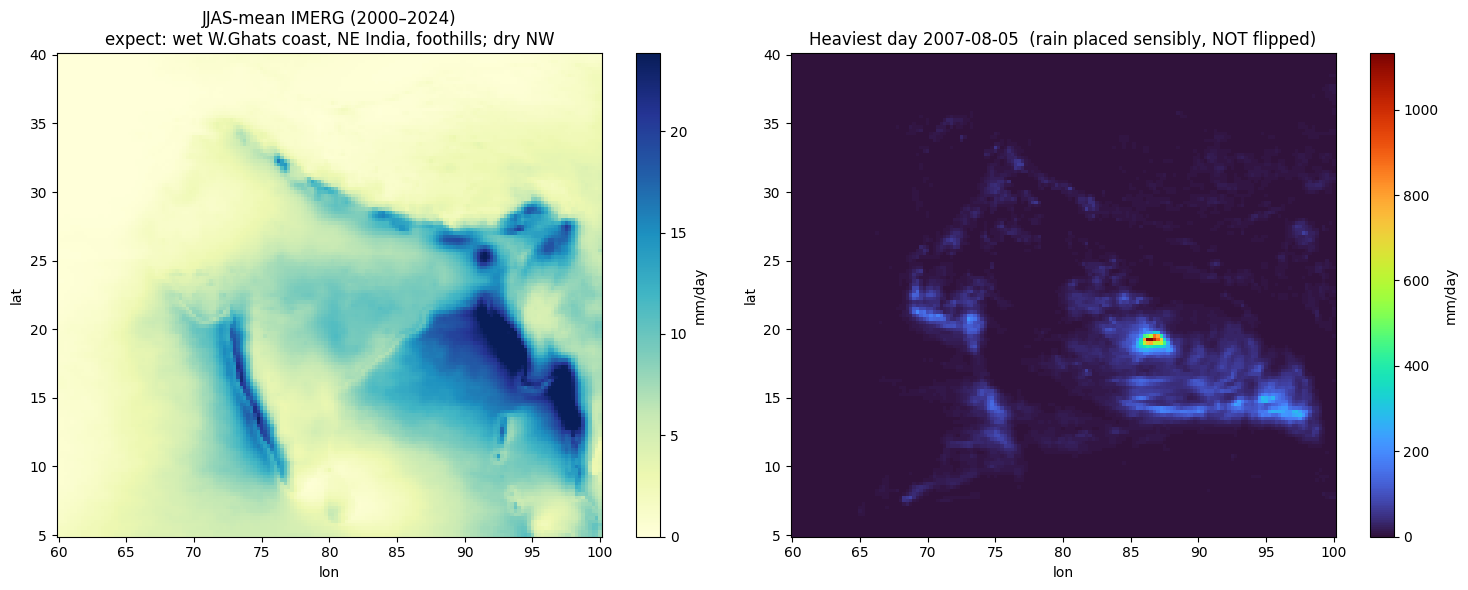

peak 1132 mm/day on 2007-08-05


In [5]:
LON, LAT = np.meshgrid(im_lon, im_lat)
clim = np.nanmean(imerg.values, axis=0)
hi   = int(np.nanargmax(imerg.values.max(axis=(1,2))))
day  = imerg.values[hi]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
m0=ax[0].pcolormesh(LON,LAT,clim,cmap='YlGnBu',vmin=0,vmax=np.nanpercentile(clim,99),shading='auto')
ax[0].set_title("JJAS-mean IMERG (2000–2024)\nexpect: wet W.Ghats coast, NE India, foothills; dry NW")
plt.colorbar(m0,ax=ax[0],label='mm/day'); ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat')
m1=ax[1].pcolormesh(LON,LAT,day,cmap='turbo',shading='auto')
ax[1].set_title(f"Heaviest day {str(im_time[hi])[:10]}  (rain placed sensibly, NOT flipped)")
plt.colorbar(m1,ax=ax[1],label='mm/day'); ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat')
plt.tight_layout(); plt.show()
print(f"peak {np.nanmax(day):.0f} mm/day on {str(im_time[hi])[:10]}")

In [6]:
# ── IMERG SETUP : load + mask + threshold + 8-connectivity labeling (run FIRST) ──
# Mirrors the ERA5 check-6 SETUP, with the IMERG-specific changes:
#   • single file; coords are 'lat'/'lon' (NOT 'latitude'/'longitude')
#   • var 'tp' already in mm/day
#   • per-grid p99 thresholds RECOMPUTED on IMERG (★ do NOT reuse ERA5's)
# Variable names (data_precip, lat, lon, times_pd, india_mask, Label8, NE8_raw)
# are kept identical so the canonical run_tracking_mean() cell runs unchanged.
import numpy as np, pandas as pd, xarray as xr, glob, subprocess, warnings
from scipy import ndimage
warnings.filterwarnings("ignore")

subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

# --- load IMERG (single file; coords lat/lon; tp in mm/day) ---
IMERG_PATH = '/kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc'
if not glob.glob(IMERG_PATH):                       # fallback if the path moved
    cand = [f for f in glob.glob('/kaggle/input/**/*.nc', recursive=True) if 'imerg' in f.lower()]
    assert cand, "IMERG .nc not found under /kaggle/input"
    IMERG_PATH = cand[0]
print("IMERG file:", IMERG_PATH)

ds = xr.open_dataset(IMERG_PATH)
data_precip = ds['tp'].values.astype('float32')          # (3050,141,161) mm/day
lat  = ds['lat'].values.astype('float32')                # 40 -> 5  (descending)
lon  = ds['lon'].values.astype('float32')                # 60 -> 100
times_pd = pd.to_datetime(ds['time'].values)
ds.close()
print(f"shape : {data_precip.shape}   time : {str(times_pd[0])[:10]} -> {str(times_pd[-1])[:10]}")
print(f"lat {lat[0]}->{lat[-1]} ({len(lat)})  lon {lon[0]}->{lon[-1]} ({len(lon)})")
print(f"NaN frac {np.isnan(data_precip).mean():.4f} | neg {(data_precip<0).sum()} | "
      f"min/mean/max {np.nanmin(data_precip):.2f}/{np.nanmean(data_precip):.2f}/{np.nanmax(data_precip):.0f}")

# --- Section 1 : India mask + per-grid threshold (RECOMPUTED on IMERG) ---
RAINY_DAY_MIN, PERCENTILE, FLOOR_MM = 1.0, 99.0, 50.0
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_mask = (countries.mask(lon, lat).values == 98)
print(f"India cells : {india_mask.sum()} / {len(lat)*len(lon)}")

data_masked = np.where((data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
                       data_precip, np.nan).astype('float32')
jjas_mask   = (times_pd.month >= 6) & (times_pd.month <= 9)     # all True (cube is JJAS-only)
per_grid_99 = np.nanpercentile(data_masked[jjas_mask, :, :], PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0       # sentinel blocking non-India cells (same as ERA5)

data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d = np.broadcast_to(per_grid_threshold[np.newaxis, :, :], data_precip.shape).copy()
c = (data_precip_safe > threshold_3d)
print(f"exceedance rate : {c.mean()*100:.3f}%")

# --- threshold sanity (expect HIGHER than ERA5: IMERG resolves heavier convective cores) ---
thr_in = per_grid_threshold[india_mask]
print(f"threshold (India) min/median/max = {thr_in.min():.1f} / "
      f"{np.median(thr_in):.1f} / {thr_in.max():.1f} mm/day")
print(f"India cells pinned to the {FLOOR_MM:.0f} mm floor : "
      f"{(per_grid_99[india_mask] < FLOOR_MM).mean()*100:.1f}%")
leak = int((c & ~india_mask[np.newaxis, :, :]).sum())
print(f"non-India exceedance cells (born+killed by domain_exit, India results unaffected): {leak}")

# --- Section 2 : 8-connectivity labeling ---
struct8 = ndimage.generate_binary_structure(2, 2)
n_days, n_lat, n_lon = data_precip.shape
Label8  = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw = np.zeros(n_days, dtype='int32')
for k in range(n_days):
    lab, nr = ndimage.label(c[k].astype('int8'), structure=struct8)
    Label8[k] = lab; NE8_raw[k] = nr
print(f"mean NE = {NE8_raw.mean():.3f} objects/day   labeling done ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.3 MB/s eta 0:00:00
IMERG file: /kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc
shape : (3050, 141, 161)   time : 2000-06-01 -> 2024-09-30
lat 40.0->5.0 (141)  lon 60.0->100.0 (161)
NaN frac 0.0000 | neg 0 | min/mean/max 0.00/5.59/1132
India cells : 4452 / 22701
exceedance rate : 0.107%
threshold (India) min/median/max = 50.0 / 71.8 / 199.8 mm/day
India cells pinned to the 50 mm floor : 14.2%
non-India exceedance cells (born+killed by domain_exit, India results unaffected): 8
mean NE = 3.566 objects/day   labeling done ✓


In [7]:
# ── MEAN tracker, NO fallback — canonical run_tracking_mean (run AFTER SETUP) ──
# Needs Label8, NE8_raw, india_mask, lat, lon, times_pd, data_precip (from SETUP).
import numpy as np, pandas as pd

OVERLAP_THRESH, MIN_TRACK_CELLS, DOMAIN_EXIT_FRAC = 0.10, 1, 0.50
n_days, n_lat, n_lon = data_precip.shape

def run_tracking_mean():
    track_stats_rows, merge_event_rows, split_event_rows = [], [], []
    active_tracks, births_per_date = {}, {}
    counters = {'track': 0, 'merge': 0, 'split': 0}

    def jjas_day_num(ts): return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

    def get_objects(day_idx):
        labeled, n_obj, objs = Label8[day_idx], NE8_raw[day_idx], {}
        for lbl in range(1, n_obj + 1):
            mask = (labeled == lbl); sz = int(mask.sum())
            if sz < MIN_TRACK_CELLS: continue
            r_, c_ = np.where(mask)
            objs[lbl] = {'size': sz,
                         'centroid': (float(lat[r_].mean()), float(lon[c_].mean())),
                         'outside': int((mask & ~india_mask).sum())}
        return objs

    def compute_overlaps(dt, dt1, ot, ot1):
        lab_t, lab_t1, pairs = Label8[dt], Label8[dt1], {}
        for li in ot:
            mi = (lab_t == li)
            for lj in np.unique(lab_t1[mi]):
                if lj == 0 or lj not in ot1: continue
                sh = int((mi & (lab_t1 == lj)).sum())
                if sh == 0: continue
                fwd, bwd = sh / ot[li]['size'], sh / ot1[lj]['size']
                pairs[(li, lj)] = (fwd, bwd, sh, (fwd + bwd) / 2.0)   # MEAN
        return pairs

    def domain_exit(o): return (o['outside'] / o['size']) > DOMAIN_EXIT_FRAC

    def new_track(di, lbl, o, start_type, split_from=-1):
        counters['track'] += 1; tnum, ts = counters['track'], times_pd[di]
        ds = ts.strftime('%Y%m%d')
        births_per_date[ds] = births_per_date.get(ds, 0) + 1
        tid = f"{ds}_{births_per_date[ds]:03d}"; clat, clon = o['centroid']
        row = {'track_num': tnum, 'track_id': tid, 'date': ds, 'year': ts.year,
               'jjas_day': jjas_day_num(ts), 'day_of_track': 0, 'size': o['size'],
               'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
               'merge_event': False, 'split_event': False, 'link_type': 'birth',
               'link_sh': 0, 'link_score': np.nan,
               'start_type': start_type, 'end_type': None, 'duration': None,
               'split_from_track': split_from, 'merge_into_track': -1, 'day_lbl': lbl}
        active_tracks[tnum] = {'track_id': tid, 'last_day': di, 'last_lbl': lbl,
                               'last_centroid': o['centroid'], 'last_size': o['size'],
                               'start_type': start_type, 'duration': 1,
                               'split_from': split_from, 'daily_rows': [row]}
        return tnum

    def extend_track(tnum, di, lbl, o, merge_event=False, split_event=False,
                     link_type='overlap', link_sh=0, link_score=np.nan):
        tr = active_tracks[tnum]; tr['duration'] += 1; ts = times_pd[di]; clat, clon = o['centroid']
        tr['daily_rows'].append(
            {'track_num': tnum, 'track_id': tr['track_id'], 'date': ts.strftime('%Y%m%d'),
             'year': ts.year, 'jjas_day': jjas_day_num(ts), 'day_of_track': tr['duration'] - 1,
             'size': o['size'], 'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
             'merge_event': merge_event, 'split_event': split_event, 'link_type': link_type,
             'link_sh': int(link_sh),
             'link_score': (round(float(link_score), 4) if link_score == link_score else np.nan),
             'start_type': tr['start_type'], 'end_type': None, 'duration': None,
             'split_from_track': tr['split_from'], 'merge_into_track': -1, 'day_lbl': lbl})
        tr['last_day'], tr['last_lbl'] = di, lbl
        tr['last_centroid'], tr['last_size'] = o['centroid'], o['size']

    def terminate_track(tnum, end_type, merge_into=-1):
        tr = active_tracks[tnum]; dur = tr['duration']; rows = tr['daily_rows']
        for r in rows: r['duration'] = dur
        rows[-1]['end_type'] = end_type; rows[-1]['merge_into_track'] = merge_into
        track_stats_rows.extend(rows); del active_tracks[tnum]

    for lbl, o in get_objects(0).items():
        tn = new_track(0, lbl, o, 'season_start')
        if domain_exit(o): terminate_track(tn, 'domain_exit')

    for di in range(n_days - 1):
        ts_today, ts_next = times_pd[di], times_pd[di + 1]
        if ts_today.month == 9 and ts_today.day == 30:
            for tn in list(active_tracks): terminate_track(tn, 'season_end')
            for lbl, o in get_objects(di + 1).items():
                tn = new_track(di + 1, lbl, o, 'season_start')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue
        ot, ot1 = get_objects(di), get_objects(di + 1)
        if len(ot1) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            continue
        if len(ot) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            for lbl, o in ot1.items():
                tn = new_track(di + 1, lbl, o, 'natural_birth')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue

        pairs = compute_overlaps(di, di + 1, ot, ot1)
        fwd_links, bwd_links = {}, {}
        for (li, lj), (f, b, sh, sc) in pairs.items():
            fwd_links.setdefault(li, []).append((lj, f, b, sh, sc))
            bwd_links.setdefault(lj, []).append((li, f, b, sh, sc))
        lbl_to_track = {tr['last_lbl']: tn for tn, tr in active_tracks.items() if tr['last_day'] == di}
        handled_today, handled_next = set(), set()

        # STEP 1 : MERGES
        mc = []
        for lj in ot1:
            par = [(li, f, b, sh, sc) for (li, f, b, sh, sc) in bwd_links.get(lj, [])
                   if sc >= OVERLAP_THRESH and li in lbl_to_track]
            if len(par) >= 2: mc.append((sum(p[4] for p in par), lj, par))
        mc.sort(key=lambda x: x[0], reverse=True)
        for combined, lj, par in mc:
            if lj in handled_next or any(p[0] in handled_today for p in par): continue
            par = [p for p in par if lbl_to_track.get(p[0]) in active_tracks]
            if len(par) < 2: continue
            par.sort(key=lambda p: ot[p[0]]['size'], reverse=True)
            obj_j = ot1[lj]; dom_li = par[0][0]; dom_tn = lbl_to_track[dom_li]
            absorbed = par[1:]; absorbed_tns = [lbl_to_track[p[0]] for p in absorbed]
            clat_j, clon_j = obj_j['centroid']; counters['merge'] += 1
            merge_event_rows.append(
                {'merge_id': counters['merge'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next), 'dominant_track': dom_tn,
                 'absorbed_tracks': ','.join(str(t) for t in absorbed_tns),
                 'n_absorbed': len(absorbed_tns), 'merged_size_after': obj_j['size'],
                 'centroid_lat': round(clat_j, 3), 'centroid_lon': round(clon_j, 3)})
            extend_track(dom_tn, di + 1, lj, obj_j, merge_event=True, link_type='merge',
                         link_sh=par[0][3], link_score=par[0][4])
            for atn in absorbed_tns: terminate_track(atn, 'merge_death', merge_into=dom_tn)
            for p in par: handled_today.add(p[0])
            handled_next.add(lj)

        # STEP 2 : SPLITS
        for li, obj_i in ot.items():
            if li in handled_today or li not in lbl_to_track: continue
            par_tn = lbl_to_track[li]
            if par_tn not in active_tracks: continue
            ch = [(lj, f, b, sh, sc) for (lj, f, b, sh, sc) in fwd_links.get(li, [])
                  if sc >= OVERLAP_THRESH and lj not in handled_next]
            if len(ch) < 2: continue
            ch.sort(key=lambda c: ot1[c[0]]['size'], reverse=True)
            dom_lj = ch[0][0]; dom_obj = ot1[dom_lj]; others = ch[1:]
            clat_i, clon_i = obj_i['centroid']
            extend_track(par_tn, di + 1, dom_lj, dom_obj, split_event=True, link_type='split',
                         link_sh=ch[0][3], link_score=ch[0][4])
            handled_today.add(li); handled_next.add(dom_lj); child_tns = []
            for co in others:
                ctn = new_track(di + 1, co[0], ot1[co[0]], 'split_birth', split_from=par_tn)
                handled_next.add(co[0]); child_tns.append(ctn)
                if domain_exit(ot1[co[0]]): terminate_track(ctn, 'domain_exit')
            counters['split'] += 1
            split_event_rows.append(
                {'split_id': counters['split'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next),
                 'parent_track': par_tn, 'child_tracks': ','.join(str(t) for t in child_tns),
                 'n_children': len(child_tns), 'parent_size': obj_i['size'],
                 'centroid_lat': round(clat_i, 3), 'centroid_lon': round(clon_i, 3)})

        # STEP 3 : CONTINUATIONS — any non-zero overlap, strongest shared wins
        cc = [(sh, li, lj) for (li, lj), (f, b, sh, sc) in pairs.items()
              if li not in handled_today and lj not in handled_next and li in lbl_to_track]
        cc.sort(key=lambda x: x[0], reverse=True)
        for sh, li, lj in cc:
            if li in handled_today or lj in handled_next: continue
            tn = lbl_to_track.get(li)
            if tn is None or tn not in active_tracks: continue
            obj_j = ot1[lj]
            extend_track(tn, di + 1, lj, obj_j, link_type='overlap',
                         link_sh=sh, link_score=pairs[(li, lj)][3])
            handled_today.add(li); handled_next.add(lj)
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

        # STEP 4 : NO FALLBACK — any active track not extended today dies
        for tn in list(active_tracks.keys()):
            tr = active_tracks.get(tn)
            if tr is None or tr['last_day'] != di: continue
            terminate_track(tn, 'natural_death')

        # STEP 5 : BIRTHS
        for lj, obj_j in ot1.items():
            if lj in handled_next: continue
            tn = new_track(di + 1, lj, obj_j, 'natural_birth')
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

    for tn in list(active_tracks): terminate_track(tn, 'season_end')

    df_stats = pd.DataFrame(track_stats_rows)
    df_merge = pd.DataFrame(merge_event_rows) if merge_event_rows else pd.DataFrame()
    df_split = pd.DataFrame(split_event_rows) if split_event_rows else pd.DataFrame()
    srows = []
    for tnum, grp in df_stats.groupby('track_num'):
        first, last = grp.iloc[0], grp.iloc[-1]
        srows.append({'track_num': tnum, 'track_id': first['track_id'],
                      'birth_date': first['date'], 'death_date': last['date'],
                      'year': int(first['year']),
                      'duration': int(first['duration']) if pd.notna(first['duration']) else len(grp),
                      'peak_size': int(grp['size'].max()),
                      'start_type': first['start_type'], 'end_type': last['end_type'],
                      'n_merge_events': int(grp['merge_event'].sum()),
                      'n_split_events': int(grp['split_event'].sum())})
    return df_stats, pd.DataFrame(srows), df_merge, df_split

stats_mean, summary_mean, merge_mean, split_mean = run_tracking_mean()

# ── Part 1, step 4 : the IMERG counts ──
print(f"IMERG  tracks={summary_mean.shape[0]:,}  merges={len(merge_mean)}  "
      f"splits={len(split_mean)}  obj-days={len(stats_mean):,}")
print("ERA5 baseline (46 yr) was: tracks=10,965  merges=173  splits=124  obj-days=13,659")
print("IMERG is 25 yr with heavier extremes + its own thresholds → counts WILL differ (expected, not a bug).")
print("columns :", stats_mean.columns.tolist())

IMERG  tracks=10,006  merges=71  splits=51  obj-days=10,877
ERA5 baseline (46 yr) was: tracks=10,965  merges=173  splits=124  obj-days=13,659
IMERG is 25 yr with heavier extremes + its own thresholds → counts WILL differ (expected, not a bug).
columns : ['track_num', 'track_id', 'date', 'year', 'jjas_day', 'day_of_track', 'size', 'centroid_lat', 'centroid_lon', 'merge_event', 'split_event', 'link_type', 'link_sh', 'link_score', 'start_type', 'end_type', 'duration', 'split_from_track', 'merge_into_track', 'day_lbl']


Top years by TRACKS:
 year
2007    628
2008    506
2013    499
2011    495
2010    492

Top years by MERGES:
 year
2005    7
2013    7
2023    5
2000    4
2008    4

Top years by SPLITS:
 year
2023    4
2012    4
2007    4
2013    3
2002    3

→ most tracks=2007 · most merges=2005 · most splits=2023


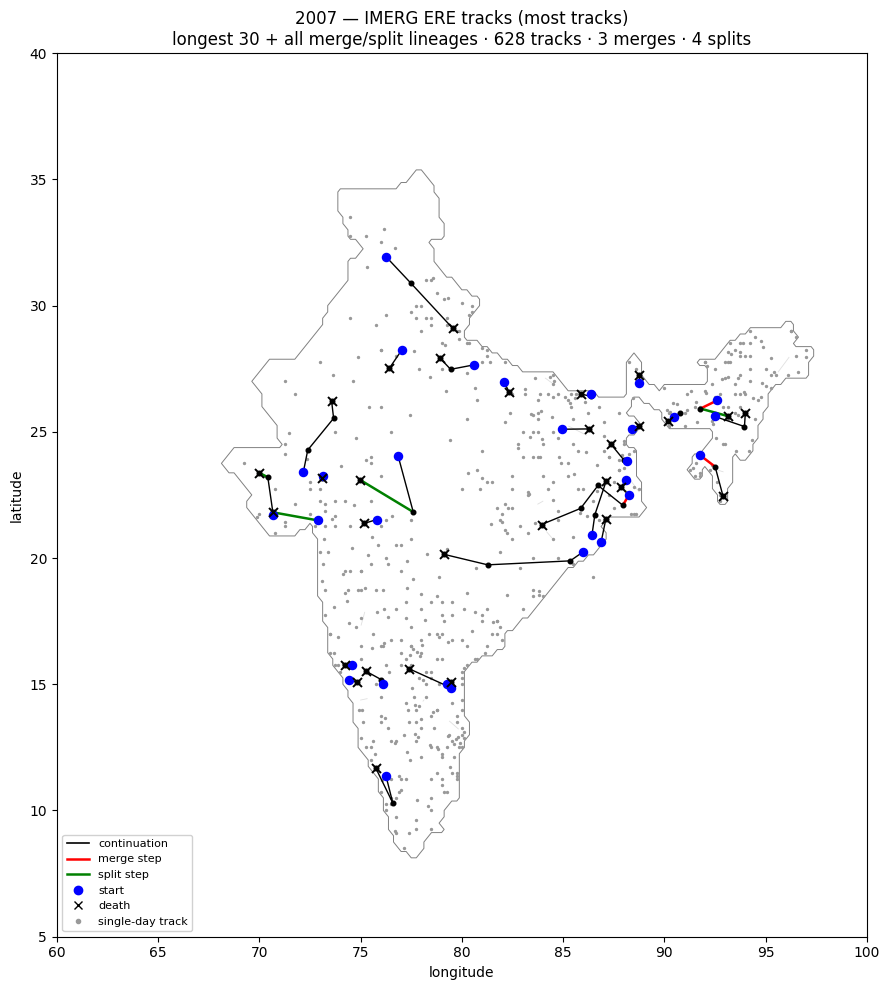

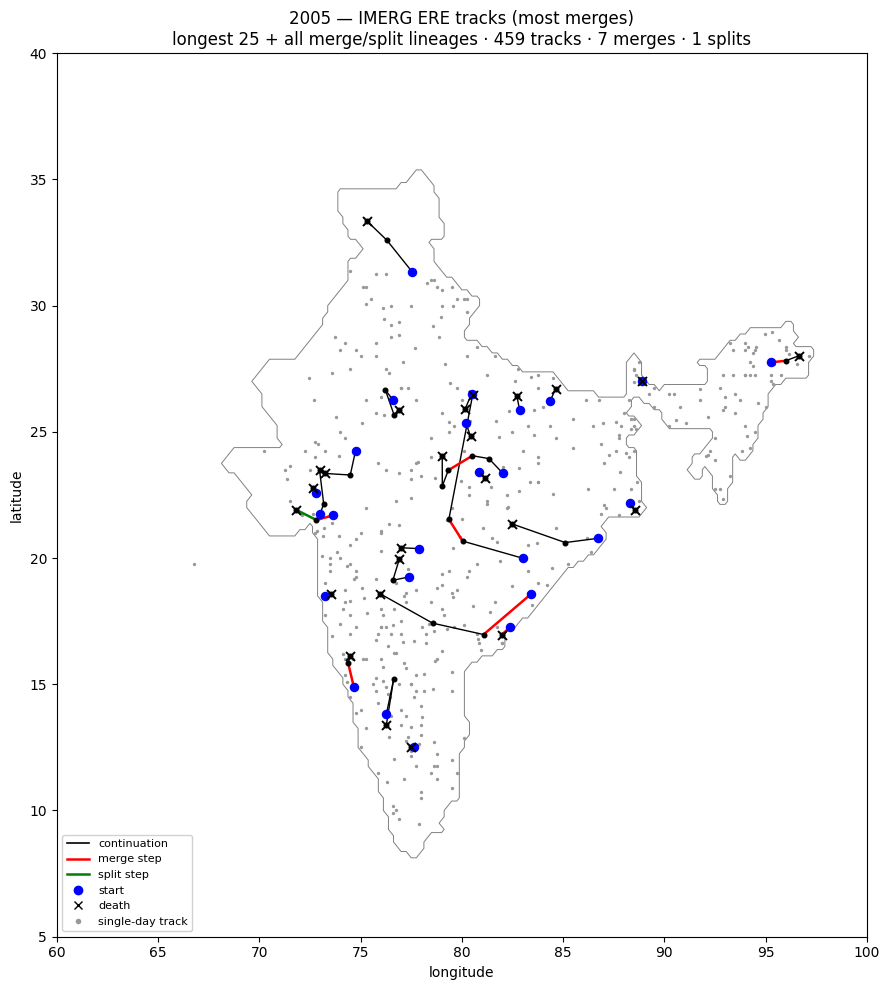

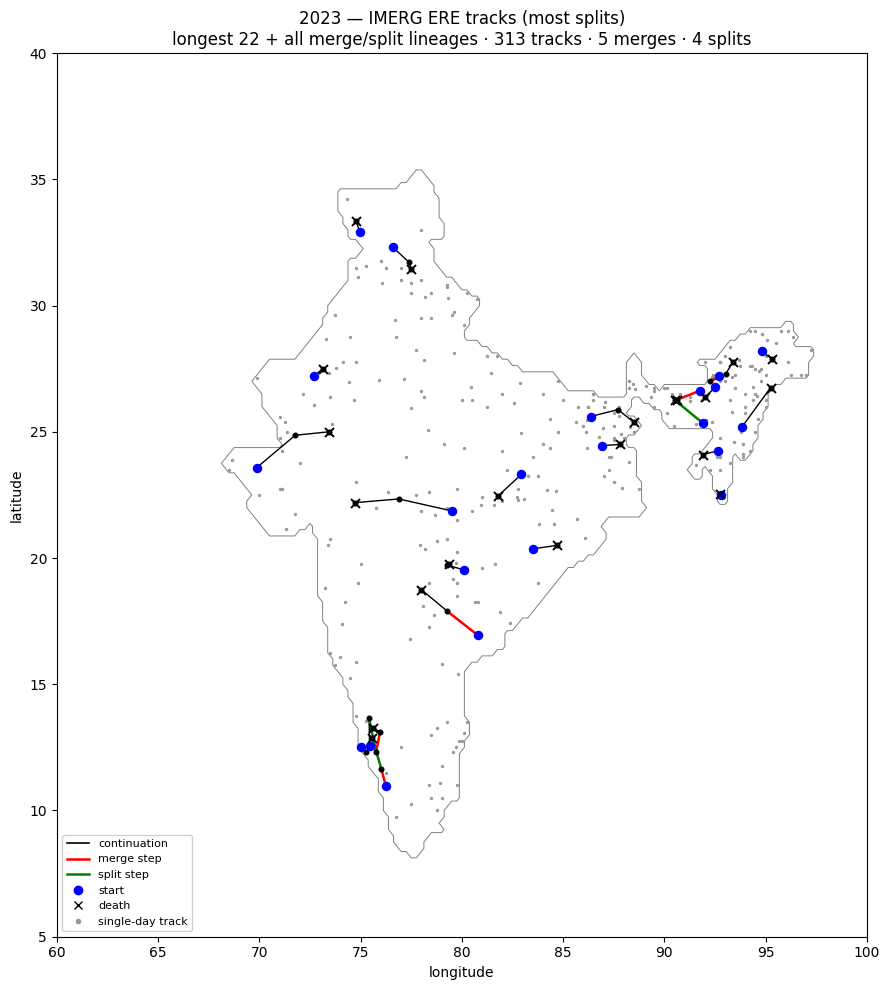

In [8]:
# ── IMERG track maps : 3 years (most tracks / merges / splits) — run AFTER tracker ──
#   black = continuation   red = merge step (dominant parent -> product)
#   green = split step (parent -> dominant daughter)   blue = start   black x = death
#   grey dot = single-day track   faint grey = other multiday tracks (context)
#   NO less-dominant-parent / split-child branch lines (per request): each track is
#   one polyline, coloured per-step by its own merge_event / split_event flag.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DEATHS = ('natural_death', 'domain_exit')   # merge_death / season_* get no x

def plot_year(year, n_longest=30, context=True, tag=""):
    syr    = summary_mean[summary_mean['year'] == year]
    multid = syr[syr['duration'] > 1].sort_values('duration', ascending=False)
    me = merge_mean[merge_mean.year == year] if len(merge_mean) else merge_mean
    se = split_mean[split_mean.year == year] if len(split_mean) else split_mean

    # focus = longest N  +  every multiday track that takes part in a merge/split
    focus = set(multid.head(n_longest)['track_num'].astype(int))
    dur   = dict(zip(syr['track_num'].astype(int), syr['duration']))
    def add_md(tn):
        if dur.get(int(tn), 1) > 1: focus.add(int(tn))
    if len(me):
        for r in me.itertuples(index=False):
            add_md(r.dominant_track)
            for t in str(r.absorbed_tracks).split(','):
                if t.strip(): add_md(int(t))
    if len(se):
        for r in se.itertuples(index=False):
            add_md(r.parent_track)
            for t in str(r.child_tracks).split(','):
                if t.strip(): add_md(int(t))

    singles     = syr[(syr['duration'] == 1) & (~syr['track_num'].isin(focus))]['track_num'].tolist()
    context_tns = [tn for tn in multid['track_num'].astype(int).tolist() if tn not in focus]

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if context:
        for tn in context_tns:
            g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color='0.88', lw=0.6, zorder=1)
    if singles:
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=8, color='0.6', marker='.', zorder=2)

    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons = g['centroid_lon'].values; lats = g['centroid_lat'].values
        mev  = g['merge_event'].values;  sev  = g['split_event'].values
        for i in range(1, len(g)):
            if   mev[i]: col, lw, z = 'red',   1.8, 4     # merge step
            elif sev[i]: col, lw, z = 'green', 1.8, 4     # split step
            else:        col, lw, z = 'black', 1.0, 2     # continuation
            ax.plot([lons[i-1], lons[i]], [lats[i-1], lats[i]], '-', color=col, lw=lw, zorder=z)
        ax.scatter(lons, lats, s=11, color='black', zorder=5)          # nodes
        ax.scatter(lons[0], lats[0], s=34, color='blue', zorder=6)     # start
        if g.iloc[-1]['end_type'] in DEATHS:                           # death
            ax.scatter(lons[-1], lats[-1], s=42, marker='x', color='black', lw=1.4, zorder=7)

    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='continuation'),
        Line2D([0],[0], color='red',   lw=1.8, label='merge step'),
        Line2D([0],[0], color='green', lw=1.8, label='split step'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
        Line2D([0],[0], marker='.', color='0.6',   lw=0, label='single-day track'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — IMERG ERE tracks ({tag})\n"
                 f"longest {min(n_longest, len(multid))} + all merge/split lineages · "
                 f"{len(syr)} tracks · {len(me)} merges · {len(se)} splits")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

# --- pick the three years ---
tracks_per_yr = summary_mean.groupby('year').size().sort_values(ascending=False)
merges_per_yr = (merge_mean.groupby('year').size().sort_values(ascending=False)
                 if len(merge_mean) else pd.Series(dtype=int))
splits_per_yr = (split_mean.groupby('year').size().sort_values(ascending=False)
                 if len(split_mean) else pd.Series(dtype=int))

print("Top years by TRACKS:\n", tracks_per_yr.head().to_string())
print("\nTop years by MERGES:\n", merges_per_yr.head().to_string() if len(merges_per_yr) else "  (none)")
print("\nTop years by SPLITS:\n", splits_per_yr.head().to_string() if len(splits_per_yr) else "  (none)")

yr_tracks = int(tracks_per_yr.idxmax())
yr_merges = int(merges_per_yr.idxmax()) if len(merges_per_yr) else yr_tracks
yr_splits = int(splits_per_yr.idxmax()) if len(splits_per_yr) else yr_tracks
print(f"\n→ most tracks={yr_tracks} · most merges={yr_merges} · most splits={yr_splits}")

plot_year(yr_tracks, n_longest=30, tag="most tracks")
plot_year(yr_merges, n_longest=30, tag="most merges")
plot_year(yr_splits, n_longest=30, tag="most splits")

most tracks=2007 · most merges=2005 · most splits=2023


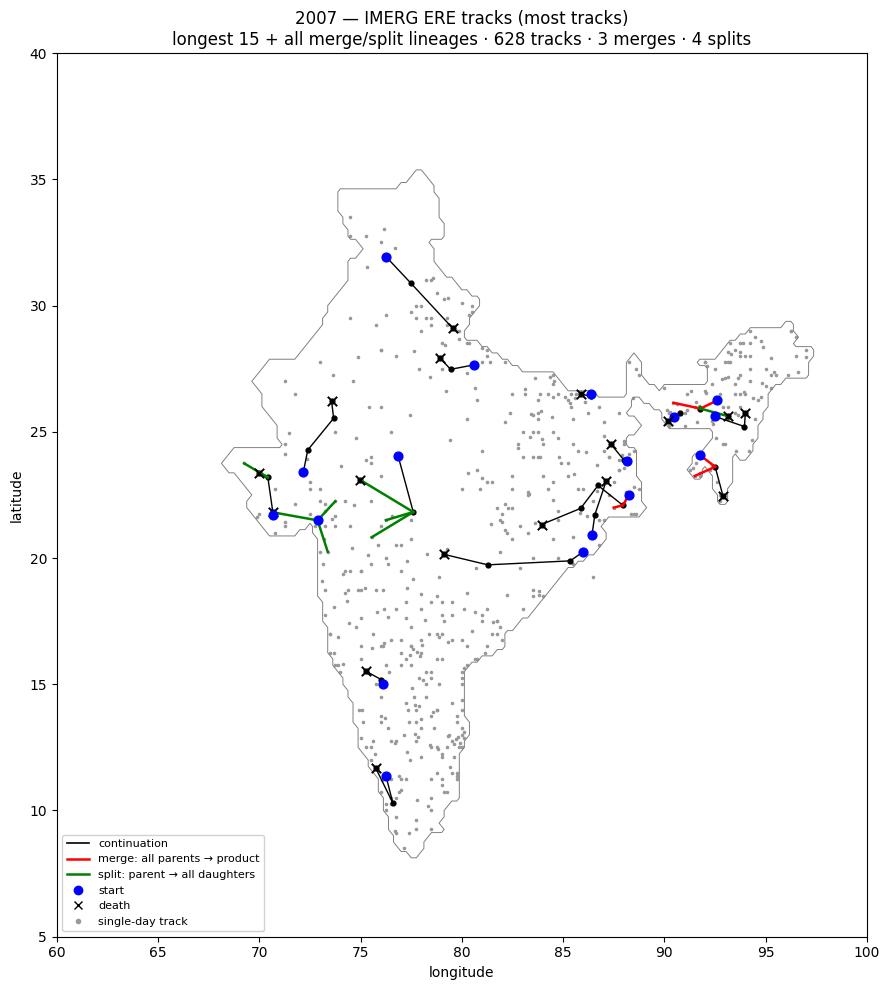

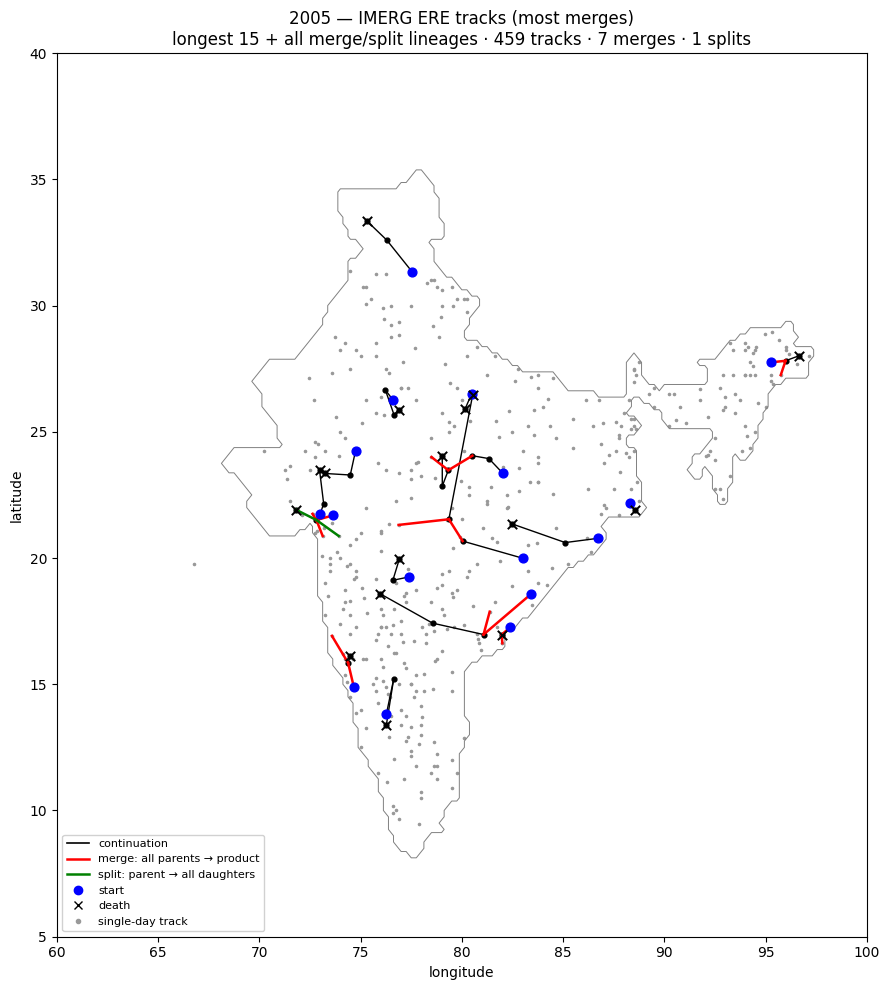

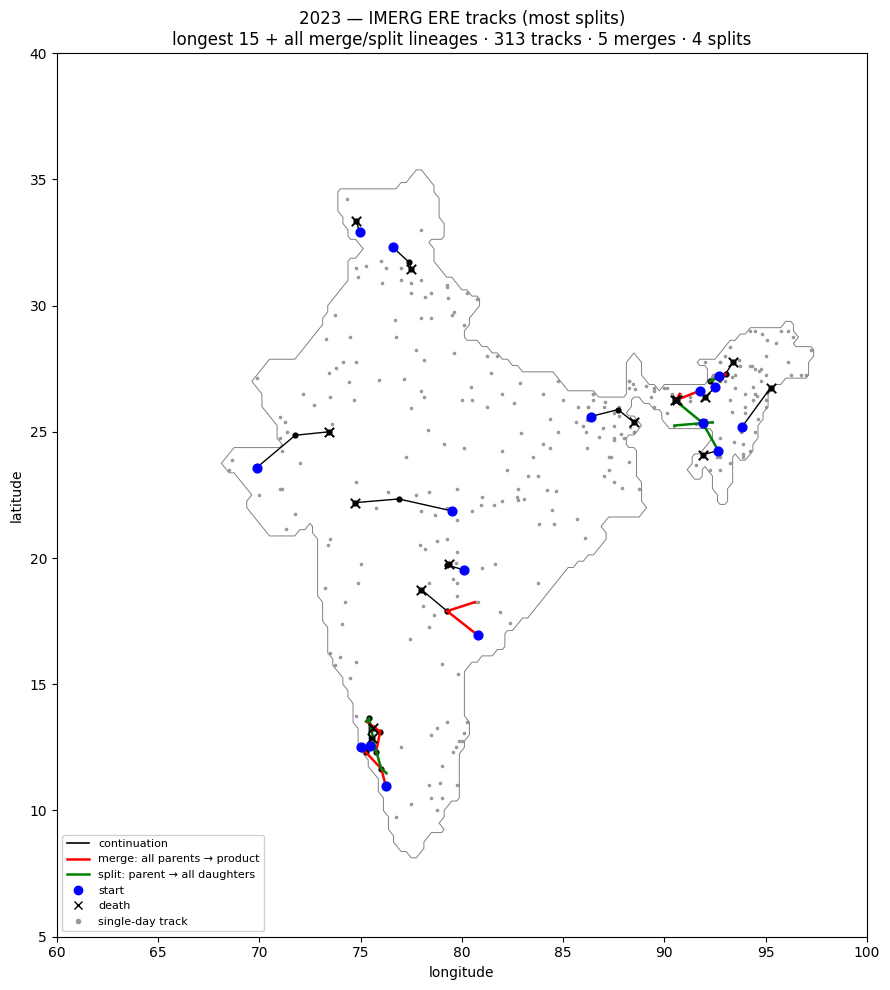

In [9]:
# ── IMERG track maps : 3 yrs (most tracks/merges/splits) · top 15 longest · FULL lineage ──
#   FULL lineage (check-6-wind convention): merge draws lines from ALL parents → product (red),
#   split draws lines from parent → ALL daughters (green). This is what shows the less-dominant
#   parents and the extra split-children that the simplified "colour-the-surviving-step" version
#   hid (it could only ever show one parent / one daughter). Run AFTER the tracker.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DEATHS   = ('natural_death', 'domain_exit')
N_LONGEST = 15

# position of every object-day, keyed by (track, date) — lineage endpoints live here even for
# short absorbed-parents / split-children that aren't among the longest tracks.
_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}
def _prev(d):
    return (pd.to_datetime(str(d), format='%Y%m%d') - pd.Timedelta(days=1)).strftime('%Y%m%d')

def plot_year(year, n_longest=N_LONGEST, tag=""):
    syr    = summary_mean[summary_mean.year == year]
    multid = syr[syr.duration > 1].sort_values('duration', ascending=False)
    me = merge_mean[merge_mean.year == year] if len(merge_mean) else merge_mean.iloc[0:0]
    se = split_mean[split_mean.year == year] if len(split_mean) else split_mean.iloc[0:0]

    # focus = 15 longest, plus every multiday track that takes part in a merge/split
    focus = set(multid.head(n_longest).track_num.astype(int))
    dur   = dict(zip(syr.track_num.astype(int), syr.duration))
    def add_md(tn):
        if dur.get(int(tn), 1) > 1: focus.add(int(tn))
    for r in me.itertuples(index=False):
        focus.add(int(r.dominant_track))
        for t in str(r.absorbed_tracks).split(','):
            if t.strip(): add_md(t)
    for r in se.itertuples(index=False):
        focus.add(int(r.parent_track))
        for t in str(r.child_tracks).split(','):
            if t.strip(): add_md(t)

    # steps that are merge/split events → drawn as red/green below, so skip them in the black pass
    flagged = set()
    for r in me.itertuples(index=False): flagged.add((int(r.dominant_track), str(r.date)))
    for r in se.itertuples(index=False): flagged.add((int(r.parent_track),   str(r.date)))
    singles = syr[syr.duration == 1].track_num.tolist()

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if singles:
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=10, color='0.6', marker='.', zorder=1)

    # black continuations + nodes + start/death for the focus tracks
    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons, lats, dates = g.centroid_lon.values, g.centroid_lat.values, g.date.values
        for k in range(1, len(g)):
            if (tn, str(dates[k])) in flagged: continue          # this step is a merge/split → red/green
            ax.plot([lons[k-1], lons[k]], [lats[k-1], lats[k]], '-', color='black', lw=1.0, zorder=3)
        ax.scatter(lons, lats, s=12, color='black', zorder=4)
        ax.scatter(lons[0], lats[0], s=40, color='blue', zorder=6)
        if g.iloc[-1].end_type in DEATHS:
            ax.scatter(lons[-1], lats[-1], s=46, marker='x', color='black', lw=1.4, zorder=6)

    # RED : every parent (dominant + absorbed) → merged product
    for r in me.itertuples(index=False):
        product = _pos.get((int(r.dominant_track), str(r.date)))
        if product is None: continue
        parents = [int(r.dominant_track)] + [int(t) for t in str(r.absorbed_tracks).split(',') if t.strip()]
        for p in parents:
            src = _pos.get((p, _prev(r.date)))
            if src: ax.plot([src[0], product[0]], [src[1], product[1]], '-', color='red', lw=1.8, zorder=5)

    # GREEN : parent → every daughter (dominant + new children)
    for r in se.itertuples(index=False):
        src = _pos.get((int(r.parent_track), _prev(r.date)))
        if src is None: continue
        daughters = [int(r.parent_track)] + [int(t) for t in str(r.child_tracks).split(',') if t.strip()]
        for d in daughters:
            tgt = _pos.get((d, str(r.date)))
            if tgt: ax.plot([src[0], tgt[0]], [src[1], tgt[1]], '-', color='green', lw=1.8, zorder=5)

    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='continuation'),
        Line2D([0],[0], color='red',   lw=1.8, label='merge: all parents → product'),
        Line2D([0],[0], color='green', lw=1.8, label='split: parent → all daughters'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
        Line2D([0],[0], marker='.', color='0.6',   lw=0, label='single-day track'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — IMERG ERE tracks ({tag})\n"
                 f"longest {min(n_longest, len(multid))} + all merge/split lineages · "
                 f"{len(syr)} tracks · {len(me)} merges · {len(se)} splits")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

# same year selection as before
tracks_per_yr = summary_mean.groupby('year').size().sort_values(ascending=False)
merges_per_yr = (merge_mean.groupby('year').size().sort_values(ascending=False) if len(merge_mean) else pd.Series(dtype=int))
splits_per_yr = (split_mean.groupby('year').size().sort_values(ascending=False) if len(split_mean) else pd.Series(dtype=int))
yr_tracks = int(tracks_per_yr.idxmax())
yr_merges = int(merges_per_yr.idxmax()) if len(merges_per_yr) else yr_tracks
yr_splits = int(splits_per_yr.idxmax()) if len(splits_per_yr) else yr_tracks
print(f"most tracks={yr_tracks} · most merges={yr_merges} · most splits={yr_splits}")

plot_year(yr_tracks, N_LONGEST, "most tracks")
plot_year(yr_merges, N_LONGEST, "most merges")
plot_year(yr_splits, N_LONGEST, "most splits")

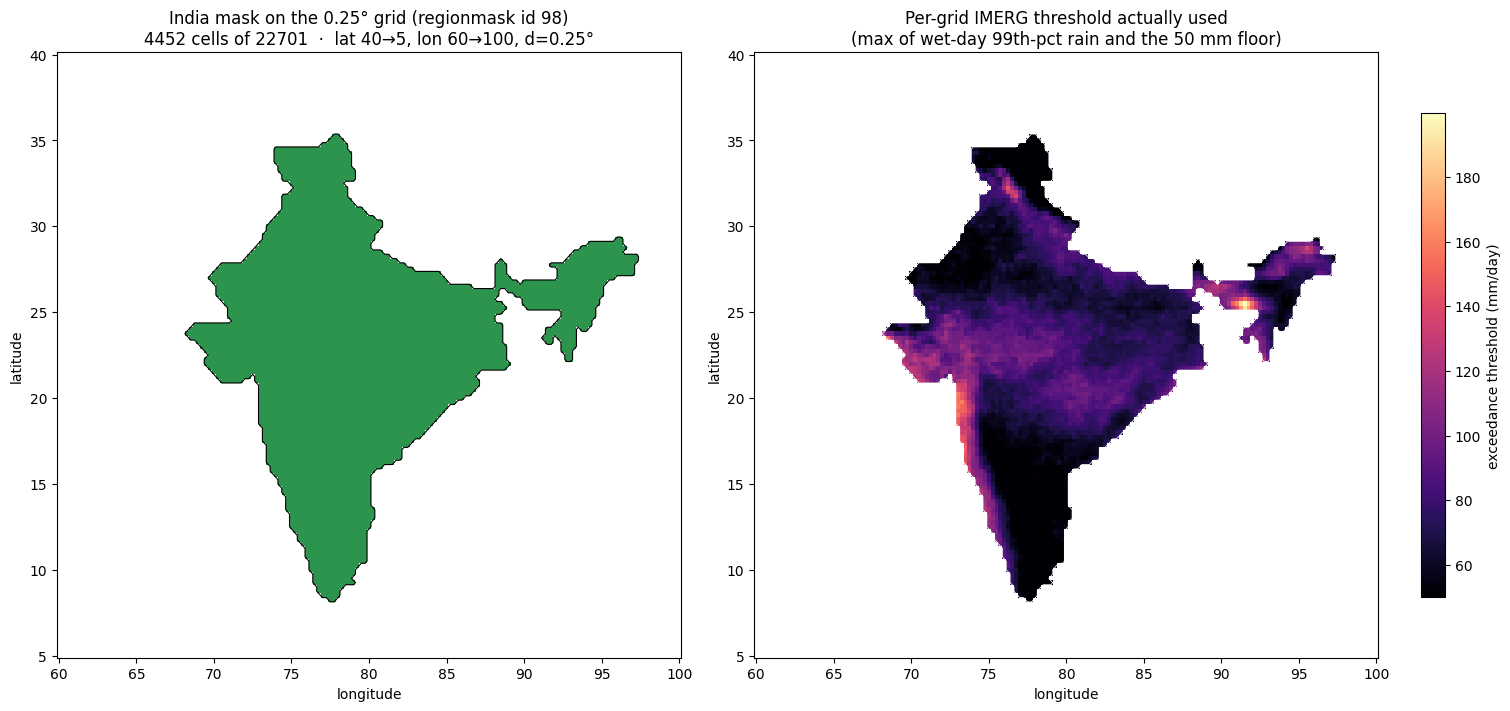

In [10]:
# ── India grid mask used by the tracker + the per-grid threshold field ──
import numpy as np, matplotlib.pyplot as plt

LON, LAT = np.meshgrid(lon, lat)
fig, ax = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

# (1) which 0.25° cells count as 'India' — the exact mask the tracker uses
m = np.where(india_mask, 1.0, np.nan)
ax[0].pcolormesh(LON, LAT, m, cmap='Greens', vmin=0, vmax=1.4, shading='auto')
ax[0].contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='black', linewidths=0.8)
ax[0].set_title(f"India mask on the 0.25° grid (regionmask id 98)\n"
                f"{int(india_mask.sum())} cells of {india_mask.size}  ·  "
                f"lat {lat[0]:.0f}→{lat[-1]:.0f}, lon {lon[0]:.0f}→{lon[-1]:.0f}, d=0.25°")
ax[0].set_xlabel("longitude"); ax[0].set_ylabel("latitude")

# (2) the exceedance threshold the tracker tests against (IMERG p99 with 50 mm floor)
thr = np.where(india_mask, per_grid_threshold, np.nan)
pm = ax[1].pcolormesh(LON, LAT, thr, cmap='magma', shading='auto')
ax[1].contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='white', linewidths=0.6)
fig.colorbar(pm, ax=ax[1], label='exceedance threshold (mm/day)', shrink=0.8)
ax[1].set_title("Per-grid IMERG threshold actually used\n(max of wet-day 99th-pct rain and the 50 mm floor)")
ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude")
plt.show()

India cells             : 4452
cells where floor binds : 632  (14.2% of India)
per_grid_99 over India  : min=4.7  median=71.8  max=199.8 mm
max amount hidden       : 45.3 mm


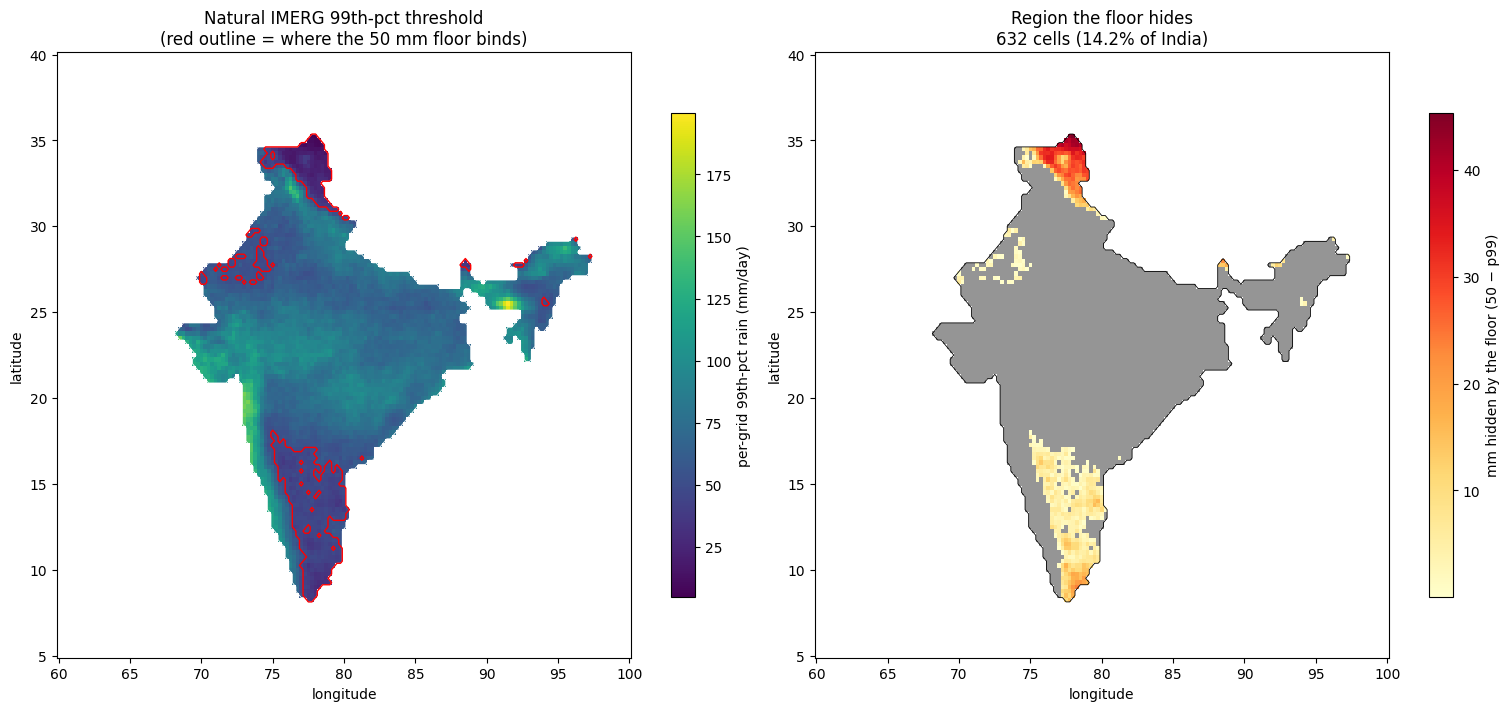

In [11]:
# ── Regions hidden by the 50 mm floor on IMERG (run AFTER SETUP) ──
import numpy as np, matplotlib.pyplot as plt

FLOOR = 50.0
p99   = np.where(india_mask, per_grid_99, np.nan)
binds = india_mask & (per_grid_99 < FLOOR)
gap   = np.where(binds, FLOOR - per_grid_99, np.nan)

n_india, n_binds = int(india_mask.sum()), int(binds.sum())
print(f"India cells             : {n_india}")
print(f"cells where floor binds : {n_binds}  ({100*n_binds/n_india:.1f}% of India)")
print(f"per_grid_99 over India  : min={np.nanmin(p99):.1f}  median={np.nanmedian(p99):.1f}  "
      f"max={np.nanmax(p99):.1f} mm")
print(f"max amount hidden       : {np.nanmax(gap):.1f} mm")

LON, LAT = np.meshgrid(lon, lat)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

ax = axes[0]
pm = ax.pcolormesh(LON, LAT, p99, cmap='viridis', shading='auto')
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='white', linewidths=0.6)
ax.contour(LON, LAT, binds.astype(int),      levels=[0.5], colors='red',   linewidths=1.0)
fig.colorbar(pm, ax=ax, label='per-grid 99th-pct rain (mm/day)', shrink=0.8)
ax.set_title('Natural IMERG 99th-pct threshold\n(red outline = where the 50 mm floor binds)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')

ax = axes[1]
base = np.where(india_mask & ~binds, 0.0, np.nan)
ax.pcolormesh(LON, LAT, base, cmap='Greys', vmin=-1, vmax=1, shading='auto')
pm2 = ax.pcolormesh(LON, LAT, gap, cmap='YlOrRd', shading='auto')
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='black', linewidths=0.6)
fig.colorbar(pm2, ax=ax, label='mm hidden by the floor (50 − p99)', shrink=0.8)
ax.set_title(f'Region the floor hides\n{n_binds} cells ({100*n_binds/n_india:.1f}% of India)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
plt.show()

In [12]:
# ── Load ERA5 850 wind + ★ match to IMERG dates by DATE not position (after SETUP) ──
import numpy as np, pandas as pd, xarray as xr, glob

WIND_PATH = '/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc'
if not glob.glob(WIND_PATH):
    cand = [f for f in glob.glob('/kaggle/input/**/*.nc', recursive=True)
            if ('wind' in f.lower() or 'uv850' in f.lower())]
    assert cand, "wind .nc not found under /kaggle/input"
    WIND_PATH = cand[0]
print("wind file:", WIND_PATH)

dw = xr.open_dataset(WIND_PATH, engine='h5netcdf')
w_lat = dw['latitude'].values if 'latitude' in dw else dw['lat'].values
w_lon = dw['longitude'].values if 'longitude' in dw else dw['lon'].values
w_time = pd.to_datetime(dw['time'].values)
u_all = dw['u'].values.astype('float32')           # (5612,141,161) eastward
v_all = dw['v'].values.astype('float32')            # (5612,141,161) northward
dw.close()
print(f"wind raw : {u_all.shape}  {str(w_time[0])[:10]} -> {str(w_time[-1])[:10]}")

# --- grid identity with IMERG (must be exact, else the footprint sampling is wrong) ---
assert len(w_lat) == len(lat) and len(w_lon) == len(lon), "wind grid size != IMERG"
assert np.allclose(w_lat, lat, atol=1e-4) and np.allclose(w_lon, lon, atol=1e-4), \
    "wind grid coords differ from IMERG — do NOT proceed"
print("grid identical to IMERG ✓")

# --- ★ THE DATE MATCH: one wind row per IMERG day, by calendar date ---
im_s = times_pd.strftime('%Y%m%d')                 # 3050 IMERG dates
w_s  = w_time.strftime('%Y%m%d')                   # 5612 wind dates
w_pos = pd.Index(w_s).get_indexer(im_s)            # wind index for each IMERG day
missing = int((w_pos < 0).sum())
print(f"IMERG days {len(im_s)} | wind days {len(w_s)} | common {len(set(im_s)&set(w_s))} "
      f"| IMERG days missing from wind: {missing}")
assert missing == 0, "some IMERG dates have no matching wind day — cannot proceed"

u_wind = u_all[w_pos]                              # (3050,141,161) aligned to times_pd/Label8
v_wind = v_all[w_pos]
wspeed = np.hypot(u_wind, v_wind).astype('float32')

# --- prove the alignment (this is what makes footprint_wind correct) ---
for i in [0, len(im_s)//2, len(im_s)-1]:
    assert w_s[w_pos[i]] == im_s[i], f"misalignment at {i}"
print(f"matched wind : {u_wind.shape}  · day-for-day perfect match verified "
      f"({im_s[0]} … {im_s[-1]}) ✓")
print("u_wind/v_wind now index EXACTLY like Label8 and times_pd.")

wind file: /kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc
wind raw : (5612, 141, 161)  1979-06-01 -> 2024-09-30
grid identical to IMERG ✓
IMERG days 3050 | wind days 5612 | common 3050 | IMERG days missing from wind: 0
matched wind : (3050, 141, 161)  · day-for-day perfect match verified (20000601 … 20240930) ✓
u_wind/v_wind now index EXACTLY like Label8 and times_pd.


Years by #multiday tracks:
 year
2007    41
2024    34
2012    31
2000    30
2019    30
2016    28
2013    27
2022    26
→ wind maps for: [2007, 2024, 2012]


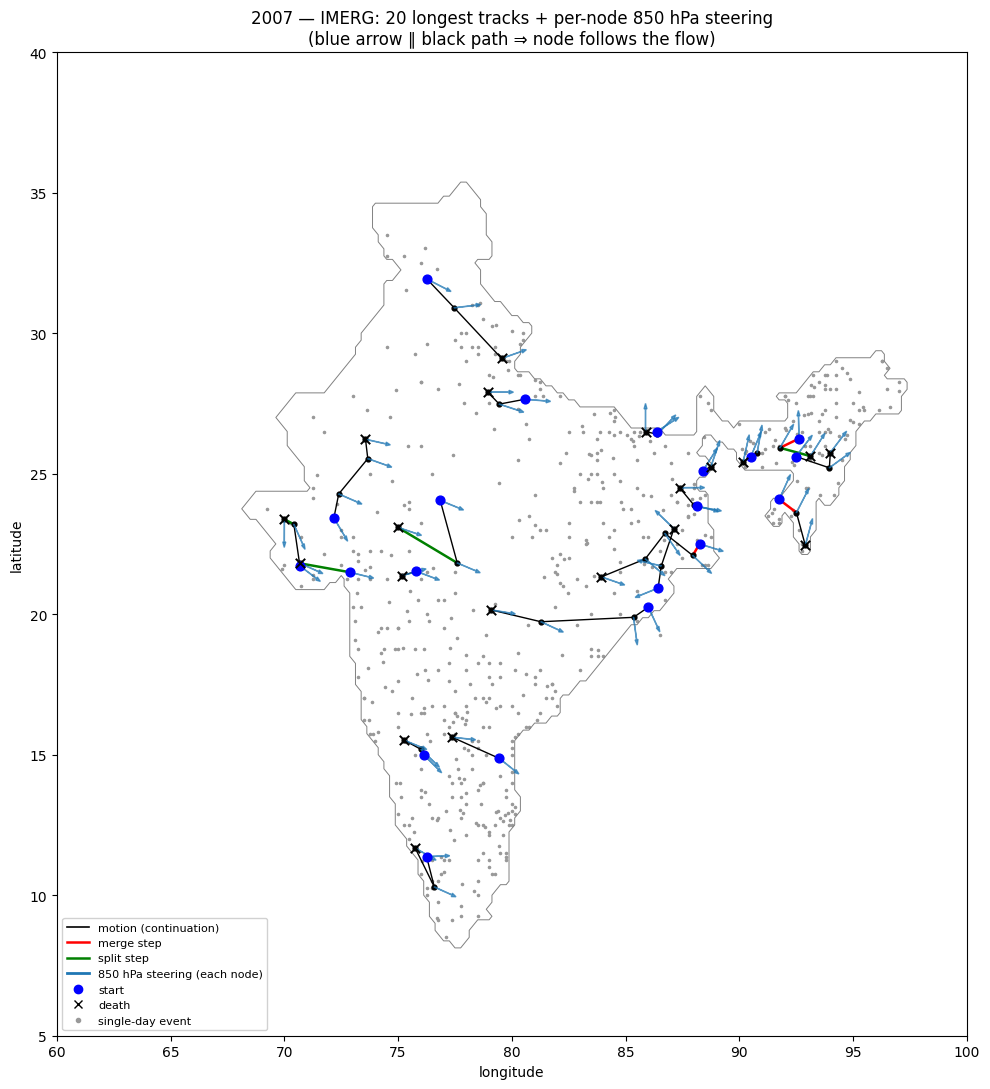

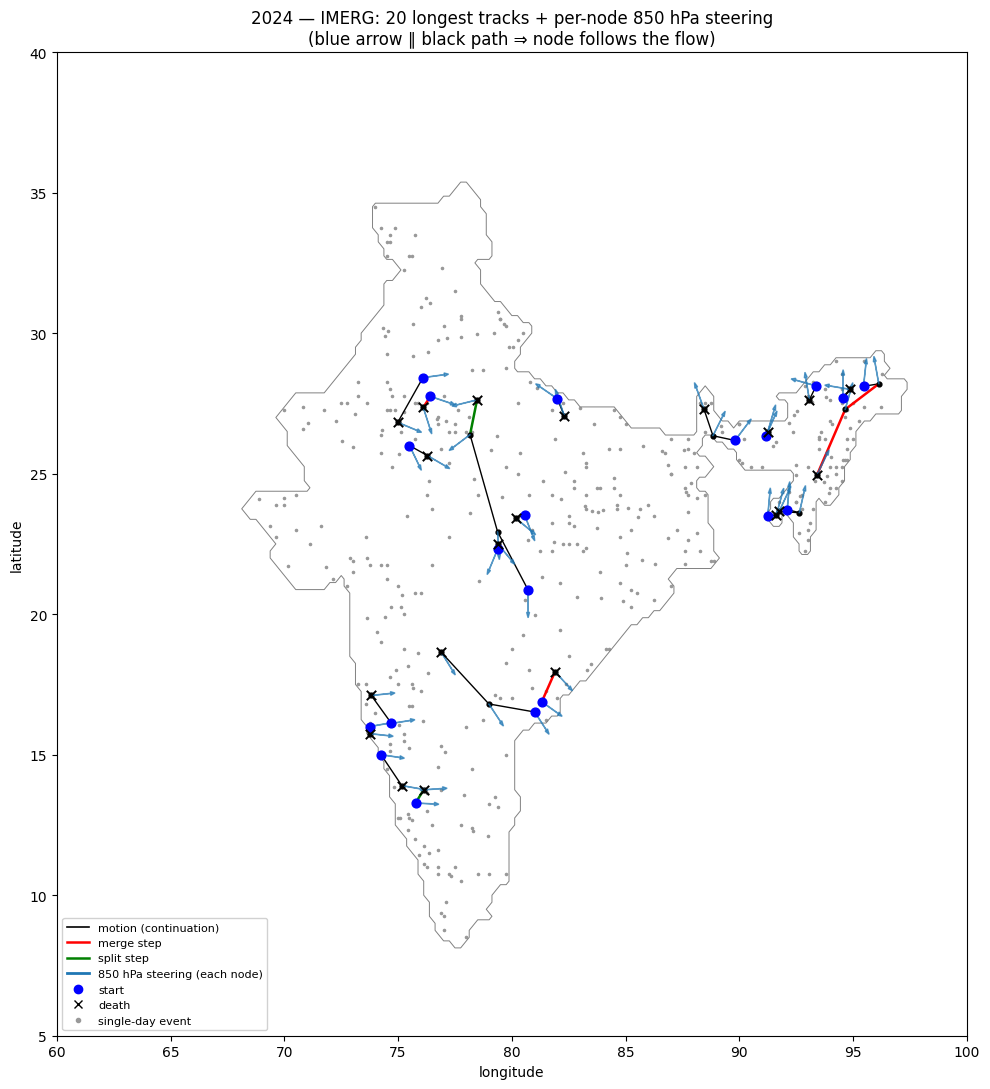

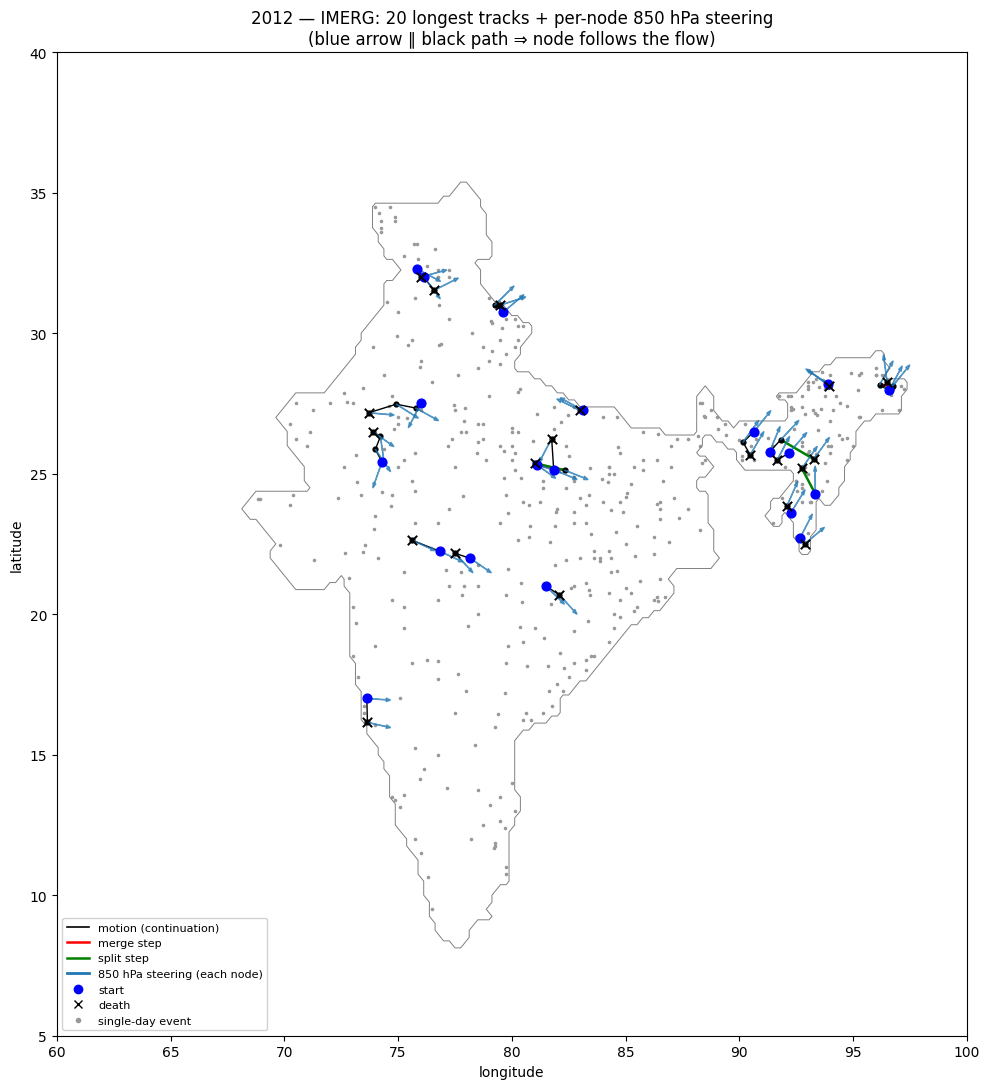

In [13]:
# ── IMERG WIND MAPS : 3 yrs (most multiday tracks) · top 20 longest · per-node 850 steering ──
#   SIMPLIFIED lineage (like the Part-2 maps): merge = red step on the surviving track,
#   split = green step on the parent. NO branch lines, NO less-dominant parents/children.
#   black = continuation · blue = start · black x = death · grey dot = single-day event
#   blue arrow at every node = 850 hPa footprint-mean wind direction (steering)
#   Run AFTER: tracker (stats_mean/summary_mean) + wind-match cell (u_wind/v_wind).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

assert u_wind.shape[0] == len(times_pd), \
    "u_wind not date-matched to IMERG — run the wind-match cell first"

# 3 years with the most MULTIDAY (duration>1) tracks
multiday_per_yr = (summary_mean[summary_mean.duration > 1].groupby('year').size()
                   .sort_values(ascending=False))
print("Years by #multiday tracks:\n", multiday_per_yr.head(8).to_string())
YEARS = [int(y) for y in multiday_per_yr.head(3).index]
N_LONGEST = 20
ARROW_DEG, DEATHS = 1.0, ('natural_death', 'domain_exit')
print("→ wind maps for:", YEARS)

date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())

def wind_lineage_map(year, n_longest=N_LONGEST):
    syr     = summary_mean[summary_mean.year == year]
    multid  = syr[syr.duration > 1].sort_values('duration', ascending=False)
    focus   = list(multid.head(n_longest).track_num.astype(int))   # top-20 longest ONLY
    singles = syr[syr.duration == 1].track_num.tolist()

    fig, ax = plt.subplots(figsize=(10, 11))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if singles:                                       # ALL single-day events (faint background)
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=10, color='0.6', marker='.', zorder=1)

    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons = g.centroid_lon.values; lats = g.centroid_lat.values
        mev  = g.merge_event.values;  sev  = g.split_event.values
        for k in range(1, len(g)):                    # colour each step by THIS track's own flag
            if   mev[k]: col, lw, z = 'red',   1.8, 4   # merge step (this track absorbed another)
            elif sev[k]: col, lw, z = 'green', 1.8, 4   # split step (this track shed a daughter)
            else:        col, lw, z = 'black', 1.0, 2   # continuation
            ax.plot([lons[k-1], lons[k]], [lats[k-1], lats[k]], '-', color=col, lw=lw, zorder=z)
        ax.scatter(lons, lats, s=12, color='black', zorder=5)              # nodes
        ax.scatter(lons[0], lats[0], s=40, color='blue', zorder=6)         # start
        if g.iloc[-1].end_type in DEATHS:                                  # death
            ax.scatter(lons[-1], lats[-1], s=46, marker='x', color='black', lw=1.4, zorder=7)
        for r in g.itertuples(index=False):           # per-node 850 hPa steering arrow
            Wu, Wv = footprint_wind(r.date, r.day_lbl); sp = np.hypot(Wu, Wv)
            if not np.isfinite(sp) or sp == 0: continue
            dx = ARROW_DEG * (Wu/sp) / np.cos(np.radians(r.centroid_lat))
            dy = ARROW_DEG * (Wv/sp)
            ax.arrow(r.centroid_lon, r.centroid_lat, dx, dy, color='tab:blue',
                     width=0.011, head_width=0.13, length_includes_head=True, zorder=5, alpha=0.7)

    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='motion (continuation)'),
        Line2D([0],[0], color='red',   lw=1.8, label='merge step'),
        Line2D([0],[0], color='green', lw=1.8, label='split step'),
        Line2D([0],[0], color='tab:blue', lw=2, label='850 hPa steering (each node)'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
        Line2D([0],[0], marker='.', color='0.6',   lw=0, label='single-day event'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — IMERG: {min(n_longest, len(multid))} longest tracks + per-node 850 hPa steering\n"
                 f"(blue arrow ∥ black path ⇒ node follows the flow)")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

for y in YEARS:
    wind_lineage_map(y)

In [14]:
# ── IMERG WIND STATS : track motion vs 850 hPa footprint wind (after tracker + wind-match) ──
import numpy as np, pandas as pd

assert u_wind.shape[0] == len(times_pd), \
    "u_wind not date-matched to IMERG — run the wind-match cell first"

KM_LAT, CELL_DEG = 110.574, 0.25
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())

md_set = set(summary_mean[summary_mean.duration > 2].track_num.astype(int))
sub = stats_mean[stats_mean.track_num.isin(md_set)].sort_values(['track_num','day_of_track'])
print(f"IMERG multiday tracks (dur>2): {len(md_set)}   object-days: {len(sub)}")

rows = []
for tn, g in sub.groupby('track_num'):
    g = g.reset_index(drop=True)
    for k in range(len(g)-1):
        a, b = g.iloc[k], g.iloc[k+1]
        mlat = 0.5*(a.centroid_lat+b.centroid_lat)
        e = (b.centroid_lon-a.centroid_lon)*111.320*np.cos(np.radians(mlat))
        n = (b.centroid_lat-a.centroid_lat)*KM_LAT
        step_km = np.hypot(e, n); d_e, d_n = e*1000/86400, n*1000/86400
        d_spd = np.hypot(d_e, d_n)
        Wu, Wv = footprint_wind(a.date, a.day_lbl); W_spd = np.hypot(Wu, Wv)
        dlt = (np.degrees(np.arctan2(d_e, d_n)) - np.degrees(np.arctan2(Wu, Wv)) + 180) % 360 - 180
        r_eq = np.sqrt(int(a['size'])*CELL_DEG**2/np.pi)*KM_LAT
        rows.append(dict(tn=int(tn), year=int(a.year), dur=len(g), dot=int(a.day_of_track),
            link=b.link_type, birth_step=(a.day_of_track==0), step_km=step_km,
            d_ms=d_spd, W_ms=W_spd, ratio=d_spd/W_spd if W_spd>0 else np.nan,
            delta=dlt, cos=np.cos(np.radians(dlt)),
            stationary=step_km < max(r_eq, 0.5*CELL_DEG*KM_LAT)))
S = pd.DataFrame(rows)
clean = S[(S.link=='overlap') & (~S.stationary) & (~S.birth_step)].copy()
evt   = S[S.link.isin(['merge','split'])]
print(f"steps {len(S)} | clean {len(clean)} | stationary {int(S.stationary.sum())} "
      f"| birth {int(S.birth_step.sum())} | merge/split {len(evt)}")

def Rp(df):
    if len(df)==0: return np.nan, np.nan, np.nan
    th = np.radians(df.delta.values); C, Sn = np.cos(th).mean(), np.sin(th).mean()
    R = np.hypot(C, Sn); return R, np.degrees(np.arctan2(Sn, C)), float(np.exp(-len(df)*R**2))

R, off, p = Rp(clean)
print("\n========  POOLED (clean multiday steps)  ========")
print(f"  ALIGNED (cos>0,|Δ|<90) : {100*(clean.cos>0).mean():.0f}%    "
      f"ANTI (cos<0,|Δ|>90) : {100*(clean.cos<0).mean():.0f}%      ← your stat")
print(f"  strictly aligned |Δ|<45 : {100*(clean.delta.abs()<45).mean():.0f}%")
print(f"  mean / median cos(Δ)    : {clean.cos.mean():+.3f} / {clean.cos.median():+.3f}")
print(f"  resultant R / offset    : {R:.3f} / {off:+.1f}°   [neg = left/NW of flow = beta drift]")
print(f"  Rayleigh p (uniformity) : {p:.2e}  ({'non-random ✓' if p<0.05 else 'cannot reject uniform ✗'})")
print(f"  median speed ratio      : {clean.ratio.median():.2f}   (|motion|/|wind|; ERA5 ≈ 0.16)")
if len(evt):
    print(f"  merge/split mean cos    : {evt.cos.mean():+.3f}   (expected worse than continuations)")

pt = clean.groupby('tn').cos.mean()
if len(pt):
    print(f"\n  per-TRACK: {100*(pt>0).mean():.0f}% net-aligned, {100*(pt<0).mean():.0f}% net-anti "
          f"(n={len(pt)} tracks with ≥1 clean step)")

print("\n--- by STEP DISPLACEMENT quartile (where the anti-alignment lives) ---")
if len(clean) >= 8:
    qs = clean.step_km.quantile([0,.25,.5,.75,1.]).values
    for i in range(4):
        c = clean[(clean.step_km>=qs[i]) & (clean.step_km<=qs[i+1])]; r,o,pp = Rp(c)
        print(f"  {qs[i]:5.0f}-{qs[i+1]:5.0f} km: n={len(c):4d}  cos={c.cos.mean():+.2f}  R={r:.2f}  p={pp:.1e}")

print("\n--- by DURATION ---")
for lo,hi,lab in [(3,3,'3 d'),(4,4,'4 d'),(5,6,'5–6 d'),(7,99,'7+ d')]:
    c = clean[(clean.dur>=lo)&(clean.dur<=hi)]; r,o,pp = Rp(c)
    if len(c): print(f"  {lab:6s}: n={len(c):4d}  cos={c.cos.mean():+.2f}  R={r:.2f}  p={pp:.1e}  ratio={c.ratio.median():.2f}")

print("\n--- by YEAR (consistency across the record) ---")
print(clean.groupby('year').agg(n=('cos','size'), cos=('cos','mean')).round(2).to_string())

IMERG multiday tracks (dur>2): 156   object-days: 536
steps 380 | clean 89 | stationary 133 | birth 156 | merge/split 74

========  POOLED (clean multiday steps)  ========
  ALIGNED (cos>0,|Δ|<90) : 31%    ANTI (cos<0,|Δ|>90) : 69%      ← your stat
  strictly aligned |Δ|<45 : 13%
  mean / median cos(Δ)    : -0.274 / -0.490
  resultant R / offset    : 0.346 / +142.4°   [neg = left/NW of flow = beta drift]
  Rayleigh p (uniformity) : 2.40e-05  (non-random ✓)
  median speed ratio      : 0.18   (|motion|/|wind|; ERA5 ≈ 0.16)
  merge/split mean cos    : -0.108   (expected worse than continuations)

  per-TRACK: 32% net-aligned, 68% net-anti (n=74 tracks with ≥1 clean step)

--- by STEP DISPLACEMENT quartile (where the anti-alignment lives) ---
     32-  107 km: n=  23  cos=-0.11  R=0.12  p=7.1e-01
    107-  163 km: n=  23  cos=-0.19  R=0.39  p=3.3e-02
    163-  226 km: n=  23  cos=-0.22  R=0.30  p=1.2e-01
    226-  678 km: n=  23  cos=-0.59  R=0.66  p=4.0e-05

--- by DURATION ---
  3 d   : 

TOTAL tracks      : 10,006
  single-day      : 9,359  (93.5%)
  multiday (>1 d) : 647  (6.5%)
  longest         : 7 days
  peak_size min/median/max = 1/2/326 cells (~713 km²/cell)

MERGES 71 — by #parents:
n_absorbed
2    55
3    15
5     1

SPLITS 51 — by #daughters:
n_children
2    40
3     9
4     1
6     1


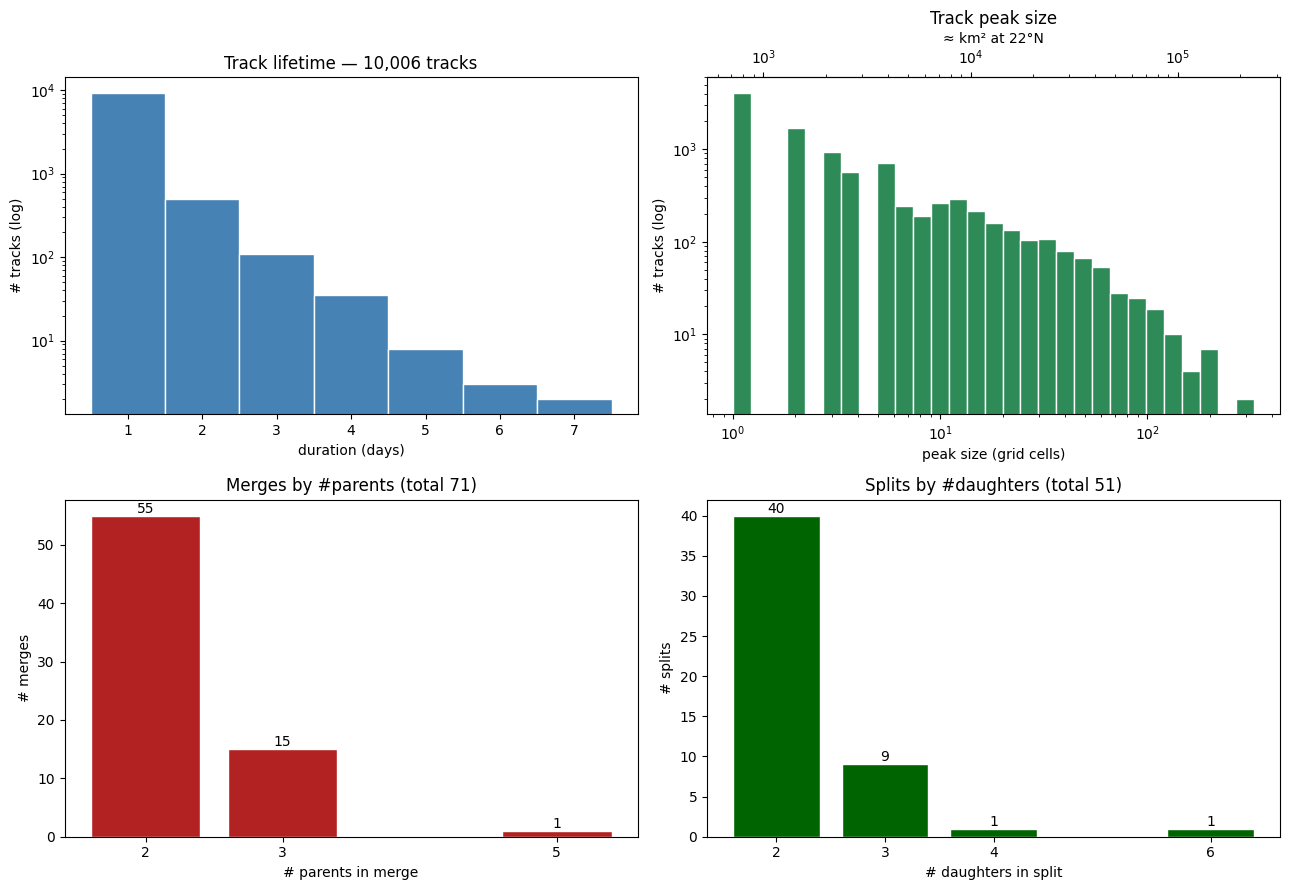

In [15]:
# ── IMERG track / merge / split distributions (run AFTER tracker) ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt

KM_LAT, CELL = 110.574, 0.25
cell_km2 = (CELL*111.320*np.cos(np.radians(22.0))) * (CELL*KM_LAT)   # ≈ km²/cell at 22°N

n_tracks = len(summary_mean); n_multi = int((summary_mean.duration > 1).sum())
print(f"TOTAL tracks      : {n_tracks:,}")
print(f"  single-day      : {n_tracks-n_multi:,}  ({100*(n_tracks-n_multi)/n_tracks:.1f}%)")
print(f"  multiday (>1 d) : {n_multi:,}  ({100*n_multi/n_tracks:.1f}%)")
print(f"  longest         : {int(summary_mean.duration.max())} days")
print(f"  peak_size min/median/max = {int(summary_mean.peak_size.min())}/"
      f"{int(summary_mean.peak_size.median())}/{int(summary_mean.peak_size.max())} cells "
      f"(~{cell_km2:.0f} km²/cell)")

parents   = (merge_mean.n_absorbed + 1) if len(merge_mean) else pd.Series(dtype=int)  # incl. dominant
daughters = (split_mean.n_children + 1) if len(split_mean) else pd.Series(dtype=int)  # incl. continuing
print(f"\nMERGES {len(merge_mean)} — by #parents:\n"
      + (parents.value_counts().sort_index().to_string() if len(parents) else "  (none)"))
print(f"\nSPLITS {len(split_mean)} — by #daughters:\n"
      + (daughters.value_counts().sort_index().to_string() if len(daughters) else "  (none)"))

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
d = summary_mean.duration.values
ax[0,0].hist(d, bins=np.arange(0.5, d.max()+1.5), color='steelblue', edgecolor='white')
ax[0,0].set_yscale('log'); ax[0,0].set_xlabel('duration (days)'); ax[0,0].set_ylabel('# tracks (log)')
ax[0,0].set_title(f'Track lifetime — {n_tracks:,} tracks')

ps = summary_mean.peak_size.values
ax[0,1].hist(ps, bins=np.logspace(0, np.log10(ps.max()+1), 30), color='seagreen', edgecolor='white')
ax[0,1].set_xscale('log'); ax[0,1].set_yscale('log')
ax[0,1].set_xlabel('peak size (grid cells)'); ax[0,1].set_ylabel('# tracks (log)')
ax[0,1].set_title('Track peak size')
ax[0,1].secondary_xaxis('top', functions=(lambda c: c*cell_km2, lambda a: a/cell_km2)).set_xlabel('≈ km² at 22°N')

if len(parents):
    vc = parents.value_counts().sort_index()
    ax[1,0].bar(vc.index.astype(int), vc.values, color='firebrick', edgecolor='white')
    for x,y in zip(vc.index.astype(int), vc.values): ax[1,0].text(x,y,str(int(y)),ha='center',va='bottom')
    ax[1,0].set_xticks(vc.index.astype(int))
ax[1,0].set_xlabel('# parents in merge'); ax[1,0].set_ylabel('# merges')
ax[1,0].set_title(f'Merges by #parents (total {len(merge_mean)})')

if len(daughters):
    vd = daughters.value_counts().sort_index()
    ax[1,1].bar(vd.index.astype(int), vd.values, color='darkgreen', edgecolor='white')
    for x,y in zip(vd.index.astype(int), vd.values): ax[1,1].text(x,y,str(int(y)),ha='center',va='bottom')
    ax[1,1].set_xticks(vd.index.astype(int))
ax[1,1].set_xlabel('# daughters in split'); ax[1,1].set_ylabel('# splits')
ax[1,1].set_title(f'Splits by #daughters (total {len(split_mean)})')
plt.tight_layout(); plt.show()

 year  dir(box)    spd  dir(India)    spd
 2000      105°   3.3         96°   4.1
 2001      112°   3.3         98°   4.0
 2002      106°   3.9         98°   4.4
 2003       99°   3.2         93°   4.0
 2004      105°   3.3         96°   4.0
 2005      102°   3.3         94°   4.0
 2006       99°   2.9         92°   3.7
 2007       92°   3.0         88°   3.9
 2008       98°   3.5         90°   4.0
 2009      108°   3.7         97°   4.2
 2010       83°   2.2         88°   3.2
 2011       93°   3.1         88°   4.0
 2012      101°   3.9         92°   4.5
 2013      102°   2.3         95°   3.7
 2014      110°   3.6         97°   4.2
 2015      105°   3.5         95°   3.9
 2016       98°   2.4         97°   3.6
 2017       99°   3.0         93°   3.7
 2018      105°   3.7         96°   4.5
 2019       89°   3.1         87°   3.8
 2020       87°   2.8         84°   3.5
 2021       88°   2.5         89°   3.4
 2022       86°   1.7         87°   2.8
 2023      106°   3.3         97°   4.

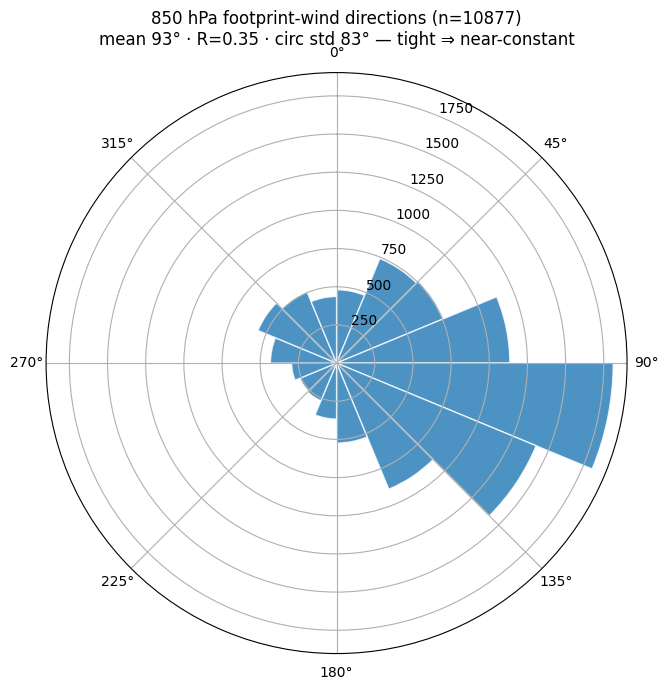

In [16]:
# ── Is 850 hPa wind a STEERING factor or a quasi-fixed background? (after wind-match) ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
assert u_wind.shape[0] == len(times_pd), "run the wind-match cell first"

def toward_deg(u, v): return np.degrees(np.arctan2(u, v)) % 360      # 0=N,90=E,180=S,270=W
def circ(deg):
    th = np.radians(np.asarray(deg)); C,S = np.cos(th).mean(), np.sin(th).mean(); R = np.hypot(C,S)
    return np.degrees(np.arctan2(S,C))%360, R, np.degrees(np.sqrt(-2*np.log(max(R,1e-9))))

years = np.array([t.year for t in times_pd]); imask = india_mask[np.newaxis,:,:]
box = (lat>=18)&(lat<=28); blon = (lon>=75)&(lon<=88)             # monsoon-trough box

print(f"{'year':>5} {'dir(box)':>9} {'spd':>6} {'dir(India)':>11} {'spd':>6}")
yd = []
for y in np.unique(years):
    sl = years==y
    ub=u_wind[sl][:,box][:,:,blon].mean(); vb=v_wind[sl][:,box][:,:,blon].mean()
    ui=np.nanmean(np.where(imask,u_wind[sl],np.nan)); vi=np.nanmean(np.where(imask,v_wind[sl],np.nan))
    yd.append(toward_deg(ub,vb))
    print(f"{y:>5} {toward_deg(ub,vb):>8.0f}° {np.hypot(ub,vb):>5.1f} {toward_deg(ui,vi):>10.0f}° {np.hypot(ui,vi):>5.1f}")

_,yR,ystd = circ(yd)
print(f"\nYEAR-TO-YEAR (box): R={yR:.3f}  circ std={ystd:.1f}°  "
      f"→ {'quasi-FIXED' if ystd<15 else 'variable'}")
ud=u_wind[:,box][:,:,blon].mean(axis=(1,2)); vd=v_wind[:,box][:,:,blon].mean(axis=(1,2))
_,dR,dstd = circ(toward_deg(ud,vd))
print(f"DAY-TO-DAY  (box): R={dR:.3f}  circ std={dstd:.1f}°  (n={len(ud)})")

# footprint winds at every object (the vectors the steering test used)
d2i = {ts.strftime('%Y%m%d'): i for i,ts in enumerate(times_pd)}; fd=[]
for r in stats_mean.itertuples(index=False):
    t=d2i[r.date]; m=(Label8[t]==int(r.day_lbl))
    if m.sum(): fd.append(toward_deg(u_wind[t][m].mean(), v_wind[t][m].mean()))
fdir,fR,fstd = circ(fd)
print(f"FOOTPRINT    : R={fR:.3f}  circ std={fstd:.1f}°  (n={len(fd)} objects)")

fig=plt.figure(figsize=(7,7)); ax=fig.add_subplot(111,projection='polar')
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
b=np.arange(0,361,22.5); cnt,_=np.histogram(fd,bins=b)
ax.bar(np.radians(b[:-1]+11.25), cnt, width=np.radians(22.5), color='tab:blue', edgecolor='white', alpha=.8)
ax.set_title(f"850 hPa footprint-wind directions (n={len(fd)})\n"
             f"mean {fdir:.0f}° · R={fR:.2f} · circ std {fstd:.0f}° — tight ⇒ near-constant", pad=20)
plt.tight_layout(); plt.show()

In [17]:
# ── LPS / vorticity-centre catalogue : locate · inspect · normalise to canonical `lps_daily` ──
# Run AFTER the tracker (needs stats_mean). Resolves the exact schema of the uploaded
# 'vorticity_center_2000-2022' dataset and emits a canonical daily centre table the
# co-location join consumes. Source column names are auto-detected; override below if a guess is wrong.
import glob, os, numpy as np, pandas as pd

# 1) locate the uploaded centre file under /kaggle/input
cands = sorted(f for f in glob.glob('/kaggle/input/**/*', recursive=True)
               if os.path.isfile(f)
               and f.lower().endswith(('.parquet', '.csv', '.txt', '.dat'))
               and any(k in f.lower() for k in ['vortic', 'lps', 'center', 'centre']))
assert cands, "No vorticity/LPS centre file found under /kaggle/input — check the dataset is attached."
print("centre-file candidates:")
for f in cands: print("  ", f)
LPS_PATH = cands[0]
print("\nusing:", LPS_PATH)

# 2) load (parquet / csv / whitespace) ---------------------------------------
if LPS_PATH.lower().endswith('.parquet'):
    raw = pd.read_parquet(LPS_PATH)
else:
    try:
        raw = pd.read_csv(LPS_PATH)
        if raw.shape[1] == 1: raise ValueError       # single column => not comma-delimited
    except Exception:
        raw = pd.read_csv(LPS_PATH, sep=r'\s+', engine='python')
print(f"\nraw shape {raw.shape}")
print("raw columns:", list(raw.columns))
print(raw.head(3).to_string())
print("\ndtypes:\n", raw.dtypes.to_string())

# 3) auto-detect the columns we need (override here if a guess is wrong) ------
def pick(keys, exclude=()):
    for c in raw.columns:
        cl = str(c).lower()
        if any(k in cl for k in keys) and not any(x in cl for x in exclude):
            return c
    return None

LAT_COL  = pick(['lat'], exclude=['med', 'median'])    # primary daily-MEAN latitude
LON_COL  = pick(['lon'], exclude=['med', 'median'])    # primary daily-MEAN longitude
DATE_COL = pick(['date', 'time'])
ID_COL   = pick(['track_id', 'system', 'sys', 'track', 'id'])
RH_COL   = pick(['rh'])                                 # moist-LPS filter (may be absent)
SF_COL   = pick(['stream', 'psi', 'sf'])               # intensity (optional)
SPAN_COL = pick(['span'])                               # positional uncertainty (optional)
print(f"\nauto-detected → lat={LAT_COL!r} lon={LON_COL!r} date={DATE_COL!r} "
      f"id={ID_COL!r} rh={RH_COL!r} streamfn={SF_COL!r} span={SPAN_COL!r}")
assert LAT_COL and LON_COL and DATE_COL, "lat/lon/date column not detected — set them manually above."

# 4) build canonical lps_daily ----------------------------------------------
lps = pd.DataFrame({
    'track_id': raw[ID_COL] if ID_COL else np.arange(len(raw)),
    'date':     pd.to_datetime(raw[DATE_COL]).dt.normalize(),
    'lat':      raw[LAT_COL].astype('float64'),
    'lon':      raw[LON_COL].astype('float64'),
})
if RH_COL:   lps['rh850']        = raw[RH_COL].astype('float64')
if SF_COL:   lps['min_streamfn'] = raw[SF_COL].astype('float64')
if SPAN_COL: lps['span_km']      = raw[SPAN_COL].astype('float64')

# collapse to one centre per (system, day) if the file is sub-daily ----------
dups = int(lps.duplicated(['track_id', 'date']).sum())
if dups:
    print(f"\n{dups} sub-daily duplicate (track_id,date) rows → collapsing to daily-mean position")
    agg = {'lat': 'mean', 'lon': 'mean'}
    for extra in ['rh850', 'min_streamfn', 'span_km']:
        if extra in lps: agg[extra] = 'mean'
    lps = lps.groupby(['track_id', 'date'], as_index=False).agg(agg)

lps_daily = lps.sort_values(['date', 'track_id']).reset_index(drop=True)

# 5) summary + coordinate-frame sanity --------------------------------------
print("\n" + "="*60); print("CANONICAL  lps_daily"); print("="*60)
print("columns:", lps_daily.columns.tolist())
print(f"system-days {len(lps_daily):,} | systems {lps_daily.track_id.nunique():,} | "
      f"dates {lps_daily.date.nunique():,}")
print(f"date range {lps_daily.date.min().date()} → {lps_daily.date.max().date()}")
print(f"lat {lps_daily.lat.min():.2f}→{lps_daily.lat.max():.2f}  "
      f"lon {lps_daily.lon.min():.2f}→{lps_daily.lon.max():.2f}")
in_frame = ((lps_daily.lon.between(60, 100)) & (lps_daily.lat.between(5, 32))).mean()
print(f"centres inside IMERG frame (lon60-100, lat5-32): {100*in_frame:.1f}%  "
      f"({'OK ✓' if in_frame > 0.95 else 'CHECK — frame mismatch?'})")
seas = lps_daily.groupby(lps_daily.date.dt.year).track_id.nunique()
print(f"~systems/season: mean {seas.mean():.1f}  (published Vishnu ≈ 14)")
if 'rh850' in lps_daily:
    print(f"rh850 present ✓  range {lps_daily.rh850.min():.0f}→{lps_daily.rh850.max():.0f}  → moist filter available")
else:
    print("rh850 ABSENT — moist filter will be skipped (proceed on all centres).")

# 6) confirm the RAIN side schema we will join against ----------------------
print("\n" + "="*60); print("RAIN OBJECT TABLE  stats_mean"); print("="*60)
print("columns:", stats_mean.columns.tolist())
print(f"object-days {len(stats_mean):,} | tracks {stats_mean.track_num.nunique():,}")
print("date dtype:", stats_mean.date.dtype, "| sample:", stats_mean.date.iloc[0])
_od = pd.to_datetime(stats_mean.date, format='%Y%m%d')
print(f"object-day date range {_od.min().date()} → {_od.max().date()}")
print(stats_mean[['track_num','date','centroid_lat','centroid_lon','size',
                  'day_of_track','duration','link_type']].head(3).to_string(index=False))

centre-file candidates:
   /kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet

using: /kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet

raw shape (2232, 10)
raw columns: ['track_id', 'date', 'lon', 'lat', 'lon_med', 'lat_med', 'n_hours', 'min_streamfn', 'rh850', 'span_km']
   track_id       date        lon        lat  lon_med  lat_med  n_hours  min_streamfn      rh850     span_km
0      8378 2000-06-02  89.214286  14.910714   89.375    14.75       14   -11280640.0  86.020816  120.942256
1      8378 2000-06-03  88.916667  14.583333   89.000    14.75       24   -12671400.0  88.603211   38.660206
2      8378 2000-06-04  86.375000  16.031250   86.500    16.00       24   -15931640.0  90.174518  385.336711

dtypes:
 track_id                 int64
date            datetime64[us]
lon                    float64
lat                    float64
lon_med                float64
lat_med                float64
n_hours   

In [18]:
# ── Co-location 4A · moist filter + date-keyed HAVERSINE nearest-centre join (after Cell 16) ──
# For every rain object-day, find the nearest LPS centre on the SAME UTC calendar date.
# Joins by DATE (never array position). Distances haversine km. Adds co-location columns to a
# COPY `stats_lps` (canonical stats_mean untouched).
import numpy as np, pandas as pd
assert 'lps_daily' in dir(), "run Cell 16 first (it builds lps_daily)"

# --- CONFIG ---
RH850_MIN = 50.0            # moist-LPS threshold (%) — used only if rh850 exists
R_LIST    = [200, 500, 800, 1000]
NEAR_R    = 500.0          # radius for n_lps_within_500km

# --- 1) moist filter (drop dry NW heat lows) ---
lps_use = lps_daily.copy()
if 'rh850' in lps_use:
    before = len(lps_use)
    lps_use = lps_use[lps_use.rh850 >= RH850_MIN].reset_index(drop=True)
    print(f"moist filter rh850≥{RH850_MIN:.0f}%: kept {len(lps_use):,}/{before:,} "
          f"system-days ({100*len(lps_use)/before:.0f}%)")
else:
    print("no rh850 column → moist filter skipped (using all centres)")

# --- 2) haversine (scalar point vs arrays) ---
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1; dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

# --- 3) index LPS centres by calendar date ---
lps_by_date = {d: (g.lat.to_numpy(), g.lon.to_numpy(), g.track_id.to_numpy())
               for d, g in lps_use.groupby('date')}

# --- 4) nearest-centre join, per object-day ---
stats_lps = stats_mean.copy()
obj_date  = pd.to_datetime(stats_lps.date, format='%Y%m%d')
n = len(stats_lps)
near_km  = np.full(n, np.nan); off_E = np.full(n, np.nan); off_N = np.full(n, np.nan)
n_within = np.zeros(n, dtype='int32')
match_id = np.empty(n, dtype=object); match_id[:] = None
KM_LAT = 110.574

for i, (d, olat, olon) in enumerate(zip(obj_date.to_numpy(),
                                        stats_lps.centroid_lat.to_numpy(),
                                        stats_lps.centroid_lon.to_numpy())):
    rec = lps_by_date.get(pd.Timestamp(d))
    if rec is None:                                # no LPS that day (incl. 2023–24 tail)
        continue
    clat, clon, cid = rec
    dist = haversine_km(olat, olon, clat, clon)
    j = int(np.argmin(dist))
    near_km[i]  = dist[j]; match_id[i] = cid[j]
    n_within[i] = int((dist <= NEAR_R).sum())
    off_E[i] = (olon - clon[j]) * 111.320 * np.cos(np.radians(0.5*(olat+clat[j])))  # +E = rain east
    off_N[i] = (olat - clat[j]) * KM_LAT                                            # +N = rain north

stats_lps['nearest_lps_km']     = near_km
stats_lps['matched_lps_id']     = match_id
stats_lps['offset_E_km']        = off_E
stats_lps['offset_N_km']        = off_N
stats_lps['n_lps_within_500km'] = n_within
stats_lps['matchable']          = ~np.isnan(near_km)
stats_lps['obj_year']           = obj_date.dt.year.to_numpy()

# --- 5) quick sanity readout (full R-curve / null / offset plots come next) ---
ov = stats_lps[stats_lps.matchable]
print(f"\nobject-days {n:,} | matchable {len(ov):,} | unmatchable {int((~stats_lps.matchable).sum()):,}")
print(f"  of which 2023–24 (no catalogue LPS by construction): {int((stats_lps.obj_year>=2023).sum()):,}")
print(f"\nnearest-LPS distance (matchable):  median {ov.nearest_lps_km.median():.0f} km | "
      f"mean {ov.nearest_lps_km.mean():.0f} km")
for R in R_LIST:
    print(f"  within {R:4d} km : {100*(ov.nearest_lps_km <= R).mean():4.1f}%")
print(f"\nmean signed offset (centre→rain):  E {ov.offset_E_km.mean():+.0f} km | "
      f"N {ov.offset_N_km.mean():+.0f} km   (expect BOTH negative ⇒ rain SW of centre)")
md = ov[ov.duration > 2]
print(f"\nmultiday-only (dur>2): n {len(md):,} | median {md.nearest_lps_km.median():.0f} km | "
      f"within 500 km {100*(md.nearest_lps_km <= 500).mean():.1f}%   (should beat single-day — key control)")

moist filter rh850≥50%: kept 2,230/2,232 system-days (100%)

object-days 10,877 | matchable 7,080 | unmatchable 3,797
  of which 2023–24 (no catalogue LPS by construction): 841

nearest-LPS distance (matchable):  median 737 km | mean 860 km
  within  200 km :  8.5%
  within  500 km : 35.1%
  within  800 km : 53.1%
  within 1000 km : 63.2%

mean signed offset (centre→rain):  E -44 km | N +155 km   (expect BOTH negative ⇒ rain SW of centre)

multiday-only (dur>2): n 395 | median 427 km | within 500 km 56.2%   (should beat single-day — key control)


clean on-system pairs: 219
mean offset   E -194 km   N -26 km
median offset E -216 km   N -47 km
in SW quadrant (W & S of centre): 58%


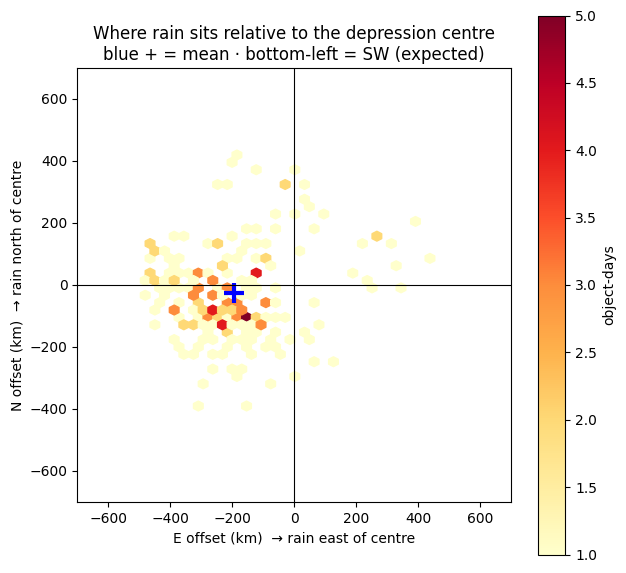

In [19]:
# ── Cleaned SW-offset : on-system matches only (3+day, ≤500 km, lat ≤ 30°N) ──
import numpy as np, matplotlib.pyplot as plt
md_tn = set(summary_mean.loc[summary_mean.duration > 2, 'track_num'])
cl = stats_lps[(stats_lps.matchable) & (stats_lps.track_num.isin(md_tn)) &
               (stats_lps.nearest_lps_km <= 500) & (stats_lps.centroid_lat <= 30)]
print(f"clean on-system pairs: {len(cl)}")
print(f"mean offset   E {cl.offset_E_km.mean():+.0f} km   N {cl.offset_N_km.mean():+.0f} km")
print(f"median offset E {cl.offset_E_km.median():+.0f} km   N {cl.offset_N_km.median():+.0f} km")
print(f"in SW quadrant (W & S of centre): {100*((cl.offset_E_km<0)&(cl.offset_N_km<0)).mean():.0f}%")

fig, ax = plt.subplots(figsize=(7, 7))
hb = ax.hexbin(cl.offset_E_km, cl.offset_N_km, gridsize=30, cmap='YlOrRd', mincnt=1)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.scatter(cl.offset_E_km.mean(), cl.offset_N_km.mean(), s=200, marker='+', color='blue', lw=3)
ax.set_xlabel('E offset (km)  → rain east of centre'); ax.set_ylabel('N offset (km)  → rain north of centre')
ax.set_title('Where rain sits relative to the depression centre\nblue + = mean · bottom-left = SW (expected)')
ax.set_xlim(-700, 700); ax.set_ylim(-700, 700); ax.set_aspect('equal')
plt.colorbar(hb, label='object-days'); plt.show()

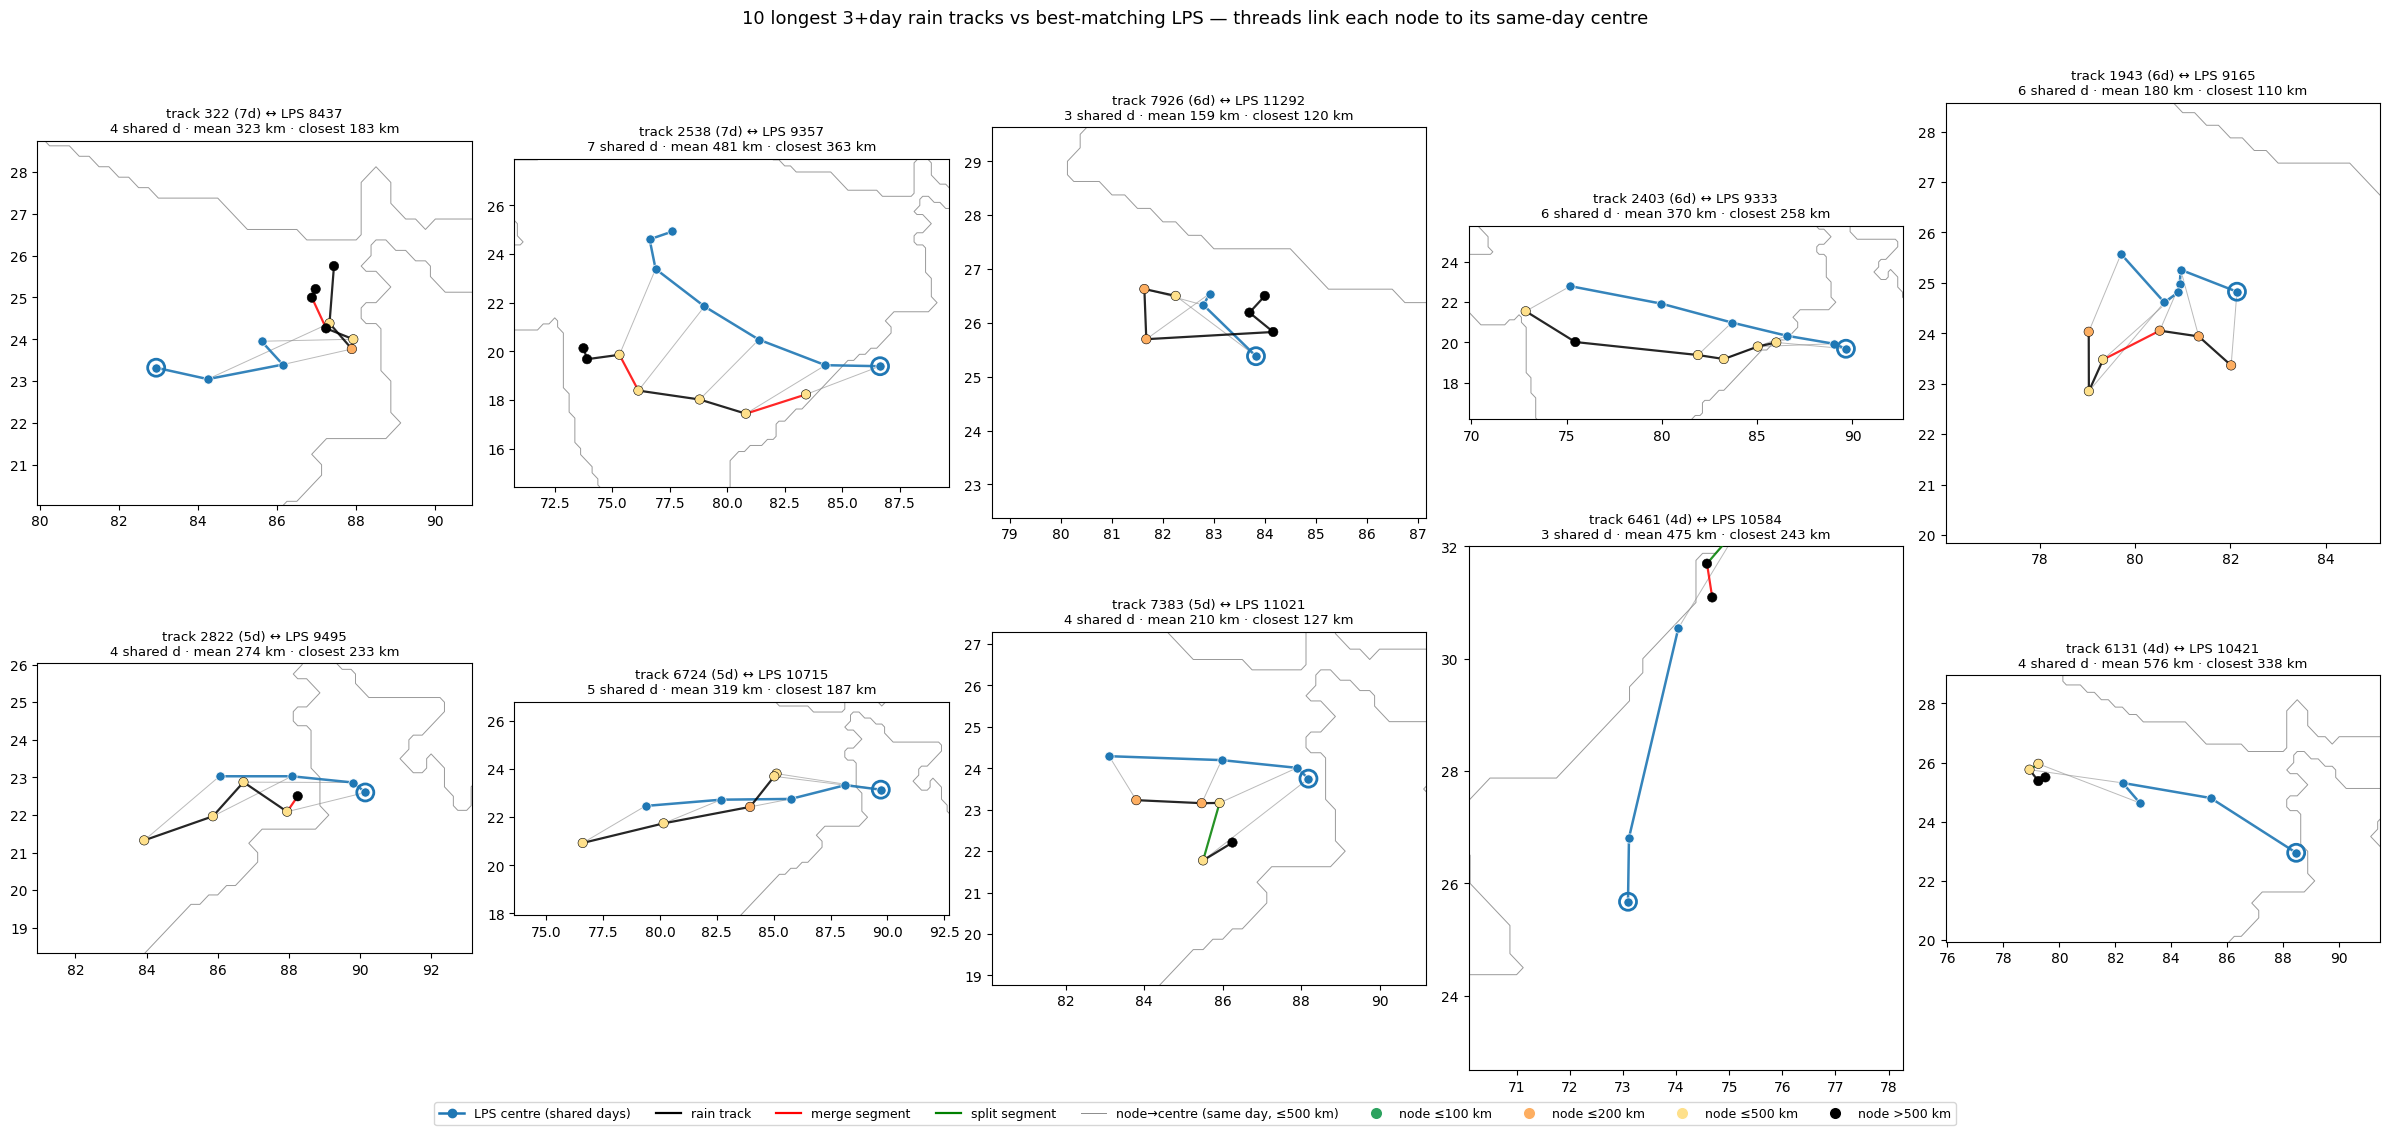

In [21]:
# ── 10 LONGEST 3+day tracks vs best-matching LPS · shared-day centres · THREAD per coloured node ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = 66, 98, 6, 32
def hav(la1, lo1, la2, lo2):
    R=6371.0088; p1,p2=np.radians(la1),np.radians(la2); dphi=p2-p1; dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))
def band_color(d):
    if d <= 100: return '#2ca25f'
    if d <= 200: return '#fdae61'
    if d <= 500: return '#fee08b'
    return 'black'

LON, LAT = np.meshgrid(lon, lat)
lps_clip  = lps_daily[(lps_daily.lon.between(LON_MIN,LON_MAX)) & (lps_daily.lat.between(LAT_MIN,LAT_MAX))]
lps_years = set(lps_clip.date.dt.year.unique())
cand = summary_mean[(summary_mean.duration > 2) & (summary_mean.year.isin(lps_years))] \
        .sort_values('duration', ascending=False)

panels = []
for tn in cand.track_num:
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    pts = dict(zip(gd, zip(g.centroid_lat, g.centroid_lon)))
    sub = lps_clip[lps_clip.date.isin(gd)]
    if not len(sub): continue
    best = None
    for SYS, sc in sub.groupby('track_id'):
        shared = [d for d in sc.date if d in pts]
        if not shared: continue
        sbd = dict(zip(sc.date, zip(sc.lat, sc.lon)))
        d2  = np.array([hav(*pts[d], *sbd[d]) for d in shared])
        n_near = int((d2 <= 500).sum()); key = (n_near, -d2.mean())
        if best is None or key > best[0]:
            best = (key, SYS, len(shared), float(d2.mean()), float(d2.min()), n_near)
    if best is None or best[5] == 0: continue
    _, SYS, ns, mmean, mmin, _ = best
    panels.append((tn, SYS, int(g.duration.iloc[0]), ns, mmean, mmin))
    if len(panels) == 10: break

fig, axes = plt.subplots(2, 5, figsize=(24, 11))
for ax, (tn, SYS, dur, ns, mmean, mmin) in zip(axes.ravel(), panels):
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    sysc = lps_clip[lps_clip.track_id == SYS].sort_values('date')
    sbd  = dict(zip(sysc.date, zip(sysc.lat, sysc.lon)))
    sysc_sh = sysc[sysc.date.isin(set(gd))]

    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='0.6', linewidths=0.7, zorder=1)

    # THREADS first (under everything): coloured node → same-day LPS centre, ≤500 km only
    for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon):
        if d in sbd:
            clat, clon = sbd[d]
            if hav(la, lo, clat, clon) <= 500:
                ax.plot([lo, clon], [la, clat], '-', color='0.55', lw=0.7, alpha=0.6, zorder=2)

    # LPS centre track (shared days): blue dots + line
    ax.plot(sysc_sh.lon, sysc_sh.lat, '-', color='tab:blue', lw=1.8, alpha=0.9, zorder=3)
    ax.scatter(sysc_sh.lon, sysc_sh.lat, s=44, color='tab:blue', edgecolor='white', lw=0.5, zorder=4)
    if len(sysc_sh):
        ax.scatter(sysc_sh.lon.iloc[0], sysc_sh.lat.iloc[0], s=150, facecolor='none',
                   edgecolor='tab:blue', lw=2, zorder=5)

    # rain track: black, merge red / split green
    for k in range(len(g)-1):
        c = 'red' if bool(g.merge_event.iloc[k+1]) else ('green' if bool(g.split_event.iloc[k+1]) else 'black')
        ax.plot(g.centroid_lon.iloc[k:k+2], g.centroid_lat.iloc[k:k+2], '-', color=c, lw=1.6, alpha=0.85, zorder=6)

    dist = np.array([hav(la, lo, *sbd[d]) if d in sbd else np.nan
                     for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon)])
    ax.scatter(g.centroid_lon, g.centroid_lat,
               c=[band_color(d) if d == d else 'black' for d in dist], s=46, edgecolor='k', lw=0.4, zorder=7)

    ax.set_title(f"track {tn} ({dur}d) ↔ LPS {SYS}\n{ns} shared d · mean {mmean:.0f} km · closest {mmin:.0f} km", fontsize=9.5)
    pad = 3
    xs = pd.concat([g.centroid_lon, sysc_sh.lon]); ys = pd.concat([g.centroid_lat, sysc_sh.lat])
    ax.set_xlim(max(LON_MIN, xs.min()-pad), min(LON_MAX, xs.max()+pad))
    ax.set_ylim(max(LAT_MIN, ys.min()-pad), min(LAT_MAX, ys.max()+pad)); ax.set_aspect(1.057)

leg = [Line2D([0],[0],color='tab:blue',marker='o',lw=1.8,label='LPS centre (shared days)'),
       Line2D([0],[0],color='black',lw=1.6,label='rain track'),
       Line2D([0],[0],color='red',lw=1.6,label='merge segment'),
       Line2D([0],[0],color='green',lw=1.6,label='split segment'),
       Line2D([0],[0],color='0.55',lw=0.7,label='node→centre (same day, ≤500 km)'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#2ca25f',markersize=9,label='node ≤100 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fdae61',markersize=9,label='node ≤200 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fee08b',markersize=9,label='node ≤500 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='black',markersize=9,label='node >500 km')]
fig.legend(handles=leg, loc='lower center', ncol=9, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("10 longest 3+day rain tracks vs best-matching LPS — threads link each node to its same-day centre",
             fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

In [22]:
# ── Duration vs distance: finer bins (<100,200,300,400,500,>500) · per object-day, matchable only ──
import numpy as np, pandas as pd
from scipy.stats import spearmanr, mannwhitneyu

om = stats_lps[stats_lps.matchable].copy()
om['dur'] = om.track_num.map(summary_mean.set_index('track_num').duration)

edges = [0,100,200,300,400,500,np.inf]
lbls  = ['<100','100-200','200-300','300-400','400-500','>500']
hdr = f"{'class':8s}{'obj-days':>9s}{'median':>8s}{'mean':>7s}" + ''.join(f"{l:>9s}" for l in lbls)
print(hdr); print('-'*len(hdr))
for lo, hi, lab in [(1,1,'1 day'),(2,2,'2 day'),(3,4,'3-4 day'),(5,6,'5-6 day'),(7,99,'7+ day')]:
    s = om[(om.dur>=lo)&(om.dur<=hi)].nearest_lps_km
    if not len(s): continue
    frac = np.histogram(s, bins=edges)[0] / len(s) * 100
    print(f"{lab:8s}{len(s):9d}{s.median():8.0f}{s.mean():7.0f}" + ''.join(f"{f:8.0f}%" for f in frac))

rho, p   = spearmanr(om.dur, om.nearest_lps_km)
pt = om.groupby('track_num').agg(dur=('dur','first'), mdist=('nearest_lps_km','mean'))
rho2, p2 = spearmanr(pt.dur, pt.mdist)
short, long = pt[pt.dur<=2].mdist, pt[pt.dur>=5].mdist
u, pu = mannwhitneyu(long, short, alternative='less')
print(f"\nSpearman(duration, distance) per object-day: rho={rho:+.3f} p={p:.1e} "
      f"({'longer = NEARER' if rho<0 else 'longer = farther'})")
print(f"Spearman(duration, mean dist) per track:     rho={rho2:+.3f} p={p2:.1e} (n={len(pt)} tracks)")
print(f"short(1-2d) median {short.median():.0f} km  vs  long(5+d) median {long.median():.0f} km "
      f"→ Mann-Whitney p={pu:.1e}")
print("NOTE: per-object-day MEAN distance (one sample/day), not closest-approach — avoids the "
      "'more draws → smaller min' artifact. Watch small-n in 5-6d / 7+d rows.")

class    obj-days  median   mean     <100  100-200  200-300  300-400  400-500     >500
--------------------------------------------------------------------------------------
1 day        6018     772    879       2%       6%       8%       8%       9%      67%
2 day         667     576    798       2%       9%      13%      11%      11%      54%
3-4 day       350     454    704       1%      11%      19%      13%       9%      47%
5-6 day        34     280    456       0%      26%      29%      18%       6%      21%
7+ day         11     425    424       0%       9%       9%      27%      27%      27%

Spearman(duration, distance) per object-day: rho=-0.106 p=5.1e-19 (longer = NEARER)
Spearman(duration, mean dist) per track:     rho=-0.057 p=5.0e-06 (n=6492 tracks)
short(1-2d) median 763 km  vs  long(5+d) median 370 km → Mann-Whitney p=8.1e-03
NOTE: per-object-day MEAN distance (one sample/day), not closest-approach — avoids the 'more draws → smaller min' artifact. Watch small-n in 5-6

In [23]:
# ── % of TRACKS by per-track MEAN same-day distance to nearest LPS (bins <100…>500) ──
import numpy as np, pandas as pd

om = stats_lps[stats_lps.matchable].copy()
om['dur'] = om.track_num.map(summary_mean.set_index('track_num').duration)
# one representative distance per track = MEAN over its matchable object-days (avoids min-artifact)
per_track = om.groupby('track_num').agg(dur=('dur','first'),
                                        mdist=('nearest_lps_km','mean'),
                                        ndays=('nearest_lps_km','size'))
edges = [0,100,200,300,400,500,np.inf]; lbls = ['<100','100-200','200-300','300-400','400-500','>500']

def band_table(df, name):
    if not len(df): print(f"{name}: none"); return
    cnt  = np.histogram(df.mdist, bins=edges)[0]; frac = cnt/len(df)*100
    print(f"\n{name}  (n={len(df)} tracks · binned by per-track MEAN same-day distance)")
    print("  " + "".join(f"{l:>10s}" for l in lbls))
    print("  " + "".join(f"{c:>10d}" for c in cnt))
    print("  " + "".join(f"{f:>9.0f}%" for f in frac))

band_table(per_track, "ALL matchable tracks")
band_table(per_track[per_track.dur > 2], "3+ day matchable tracks")

all_tn = set(summary_mean.track_num); match_tn = set(per_track.index)
print(f"\ncontext: {len(match_tn):,} tracks matchable | {len(all_tn-match_tn):,} tracks had NO LPS "
      f"on any of their days (not in table above)")
print(f"3+ day: {(summary_mean.duration>2).sum():,} total · {(per_track.dur>2).sum():,} matchable")


ALL matchable tracks  (n=6492 tracks · binned by per-track MEAN same-day distance)
        <100   100-200   200-300   300-400   400-500      >500
         130       387       526       570       564      4315
          2%        6%        8%        9%        9%       66%

3+ day matchable tracks  (n=125 tracks · binned by per-track MEAN same-day distance)
        <100   100-200   200-300   300-400   400-500      >500
           0         7        22        23        13        60
          0%        6%       18%       18%       10%       48%

context: 6,492 tracks matchable | 3,514 tracks had NO LPS on any of their days (not in table above)
3+ day: 156 total · 125 matchable


In [30]:
# ── HARDENED track-level null : multi-seed × high-B · per-object-day AND per-track · full diagnostics ──
import numpy as np, pandas as pd
def hav(la1, lo1, la2, lo2):
    R=6371.0088; p1,p2=np.radians(la1),np.radians(la2); dphi=p2-p1; dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))

# --- CONFIG ---
B        = 5000                 # shuffles per seed
SEEDS    = range(10)            # independent repeats
RADII    = (200, 300, 500)
MIN_DAYS = 1                    # set to 3 to demand ≥3 LPS-present days per track (stricter)

# --- build rigid tracks: node coords + (month,day) + own year ---
lps_ymd = {(d.year,d.month,d.day):(g.lat.to_numpy(),g.lon.to_numpy()) for d,g in lps_daily.groupby('date')}
YEARS   = np.arange(lps_daily.date.dt.year.min(), lps_daily.date.dt.year.max()+1)
sm_year = summary_mean.set_index('track_num').year
tracks  = []
for tn in summary_mean.loc[summary_mean.duration>2,'track_num']:
    g = stats_lps[stats_lps.track_num==tn].sort_values('day_of_track')
    dts = pd.to_datetime(g.date, format='%Y%m%d')
    tracks.append((g.centroid_lat.to_numpy(), g.centroid_lon.to_numpy(),
                   [(d.month,d.day) for d in dts], int(sm_year[tn])))

def summarize(year_fn):
    od, tm = [], []
    for lat, lon, md, yr in tracks:
        y = year_fn(yr); d = []
        for la, lo, (mo, dy) in zip(lat, lon, md):
            k = (y, mo, dy)
            if k in lps_ymd: a = lps_ymd[k]; d.append(hav(la, lo, a[0], a[1]).min())
        if len(d) >= MIN_DAYS:
            od.extend(d); tm.append(np.mean(d))
    return np.array(od), np.array(tm)

od_obs, tm_obs = summarize(lambda yr: yr)
print(f"observed 3+day: {len(tm_obs)} tracks · {len(od_obs)} object-days "
      f"(MIN_DAYS={MIN_DAYS}) · B={B} × {len(SEEDS)} seeds\n")

# --- collect null distributions across all seeds ---
obs = {R: (np.mean(od_obs<=R), np.mean(tm_obs<=R)) for R in RADII}
null_od = {R: [] for R in RADII}; null_tm = {R: [] for R in RADII}
for s in SEEDS:
    rng = np.random.default_rng(s)
    b_od = np.empty((B, len(RADII))); b_tm = np.empty((B, len(RADII)))
    for b in range(B):
        od, tm = summarize(lambda yr: int(rng.choice(YEARS[YEARS!=yr])))
        for j, R in enumerate(RADII):
            b_od[b, j] = np.mean(od<=R); b_tm[b, j] = np.mean(tm<=R)
    for j, R in enumerate(RADII):
        null_od[R].append(b_od[:, j]); null_tm[R].append(b_tm[:, j])

# --- report: per-seed spread of σ, ratio, and a pooled exact p ---
def report(name, obs_val, null_lists):
    pooled = np.concatenate(null_lists)                       # B*seeds draws
    ratios, sigmas, ps = [], [], []
    for arr in null_lists:                                    # one seed each
        sigmas.append((obs_val - arr.mean())/arr.std())
        ratios.append(obs_val/arr.mean())
        ps.append((np.sum(arr>=obs_val)+1)/(len(arr)+1))
    p_pool = (np.sum(pooled>=obs_val)+1)/(len(pooled)+1)
    print(f"  {name:16s} obs {100*obs_val:4.1f}% | null {100*pooled.mean():4.1f}%±{100*pooled.std():.1f}% "
          f"| ratio {np.mean(ratios):.1f}× (seed range {min(ratios):.1f}–{max(ratios):.1f}) "
          f"| σ {np.mean(sigmas):+.1f} (range {min(sigmas):+.1f}–{max(sigmas):+.1f}) "
          f"| pooled p={p_pool:.1e}")

for R in RADII:
    print(f"≤{R} km")
    report("per object-day", obs[R][0], null_od[R])
    report("per track", obs[R][1], null_tm[R])
    print()
print(f"pooled p floor = {1/(B*len(SEEDS)+1):.1e}  (over {B*len(SEEDS):,} total draws)")
print("VERDICT basis: reject 'artifact' (ratio=1) if ratios ≫1 AND stable across seeds AND pooled p tiny.")

observed 3+day: 125 tracks · 395 object-days (MIN_DAYS=1) · B=5000 × 10 seeds



KeyboardInterrupt: 

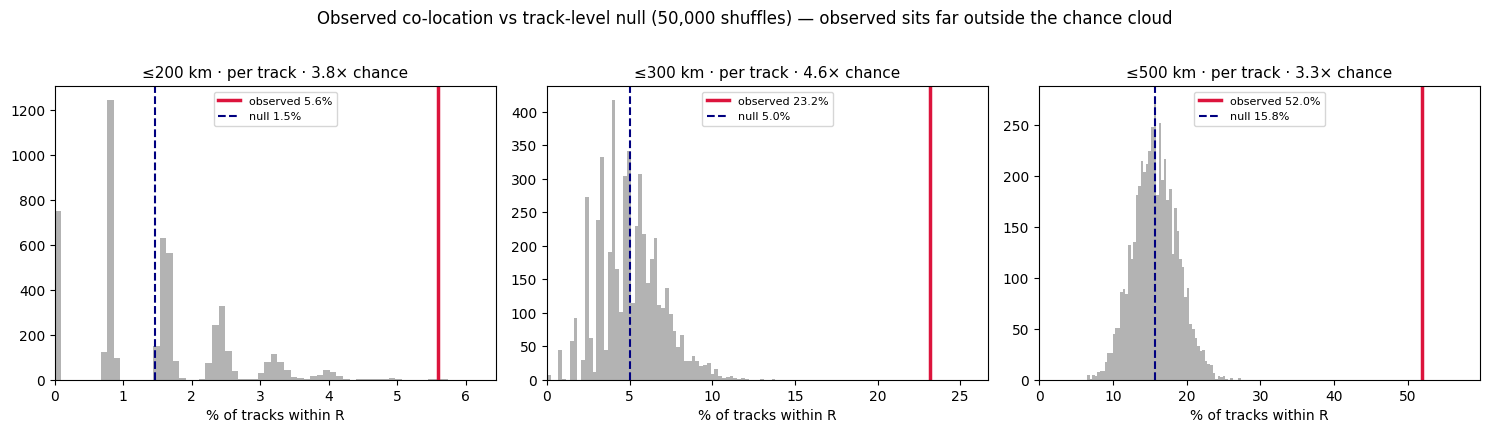

In [25]:
# ── Visual proof : observed fraction vs the full track-level null distribution (per track) ──
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(RADII), figsize=(5*len(RADII), 4.2))
for ax, R in zip(np.atleast_1d(axes), RADII):
    pooled = np.concatenate(null_tm[R]) * 100; o = obs[R][1] * 100
    ax.hist(pooled, bins=60, color='0.7', edgecolor='none')
    ax.axvline(o, color='crimson', lw=2.5, label=f'observed {o:.1f}%')
    ax.axvline(pooled.mean(), color='navy', lw=1.5, ls='--', label=f'null {pooled.mean():.1f}%')
    ax.set_title(f'≤{R} km · per track · {o/pooled.mean():.1f}× chance', fontsize=11)
    ax.set_xlabel('% of tracks within R'); ax.legend(fontsize=8)
    ax.set_xlim(0, max(o*1.15, pooled.max()*1.1))
fig.suptitle(f'Observed co-location vs track-level null ({B*len(SEEDS):,} shuffles) — '
             'observed sits far outside the chance cloud', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

Orographic tests , where are the post 500KM tracks located????

In [26]:
# ── Where do the >500 km (far / never-matched) 3+day tracks accumulate? ──
import numpy as np, pandas as pd

md_tn   = summary_mean.loc[summary_mean.duration > 2, 'track_num']
per_trk = (stats_lps[stats_lps.matchable & stats_lps.track_num.isin(md_tn)]
           .groupby('track_num').nearest_lps_km.mean())
far_tn  = set(per_trk[per_trk > 500].index) | (set(md_tn) - set(per_trk.index))   # far + never-matched
near_tn = set(per_trk[per_trk <= 500].index)
print(f"3+day tracks: {len(md_tn)} | near (≤500) {len(near_tn)} | far/never (>500) {len(far_tn)}")

def geo(tns, lab):
    g = stats_lps[stats_lps.track_num.isin(tns)]
    b = g.groupby('track_num').first()                       # genesis point per track
    reg = lambda la, lo: ('W.Ghats'  if (72<=lo<=76.5) and (8<=la<=21) else
                          'FarNorth' if la>27 else
                          'NE.hills' if (lo>90) and (la>22) else
                          'C.India'  if (75<=lo<=88) and (18<=la<=27) else 'Other')
    b['reg'] = [reg(la, lo) for la, lo in zip(b.centroid_lat, b.centroid_lon)]
    print(f"\n{lab}: {len(b)} tracks · genesis latitude median {b.centroid_lat.median():.1f}°N "
          f"· longitude median {b.centroid_lon.median():.1f}°E")
    print((b.reg.value_counts(normalize=True)*100).round(0).astype(int).to_string())
    print(f"  born >27°N (foothills): {100*(b.centroid_lat>27).mean():.0f}%  |  "
          f"born ≤76.5°E & ≤21°N (Ghats strip): {100*((b.centroid_lon<=76.5)&(b.centroid_lat<=21)).mean():.0f}%")

geo(far_tn, "FAR / never-matched (>500 km)")
geo(near_tn, "NEAR (≤500 km)  [contrast]")
print("\nEXPECT: far tracks lean W.Ghats + FarNorth; near tracks lean C.India/east. "
      "If far tracks are also mostly C.India, the orographic explanation fails.")

3+day tracks: 156 | near (≤500) 65 | far/never (>500) 91

FAR / never-matched (>500 km): 91 tracks · genesis latitude median 25.3°N · longitude median 79.6°E
reg
FarNorth    26
W.Ghats     22
Other       19
NE.hills    18
C.India     15
  born >27°N (foothills): 26%  |  born ≤76.5°E & ≤21°N (Ghats strip): 22%

NEAR (≤500 km)  [contrast]: 65 tracks · genesis latitude median 23.2°N · longitude median 82.2°E
reg
C.India     77
Other       18
NE.hills     5
  born >27°N (foothills): 0%  |  born ≤76.5°E & ≤21°N (Ghats strip): 0%

EXPECT: far tracks lean W.Ghats + FarNorth; near tracks lean C.India/east. If far tracks are also mostly C.India, the orographic explanation fails.


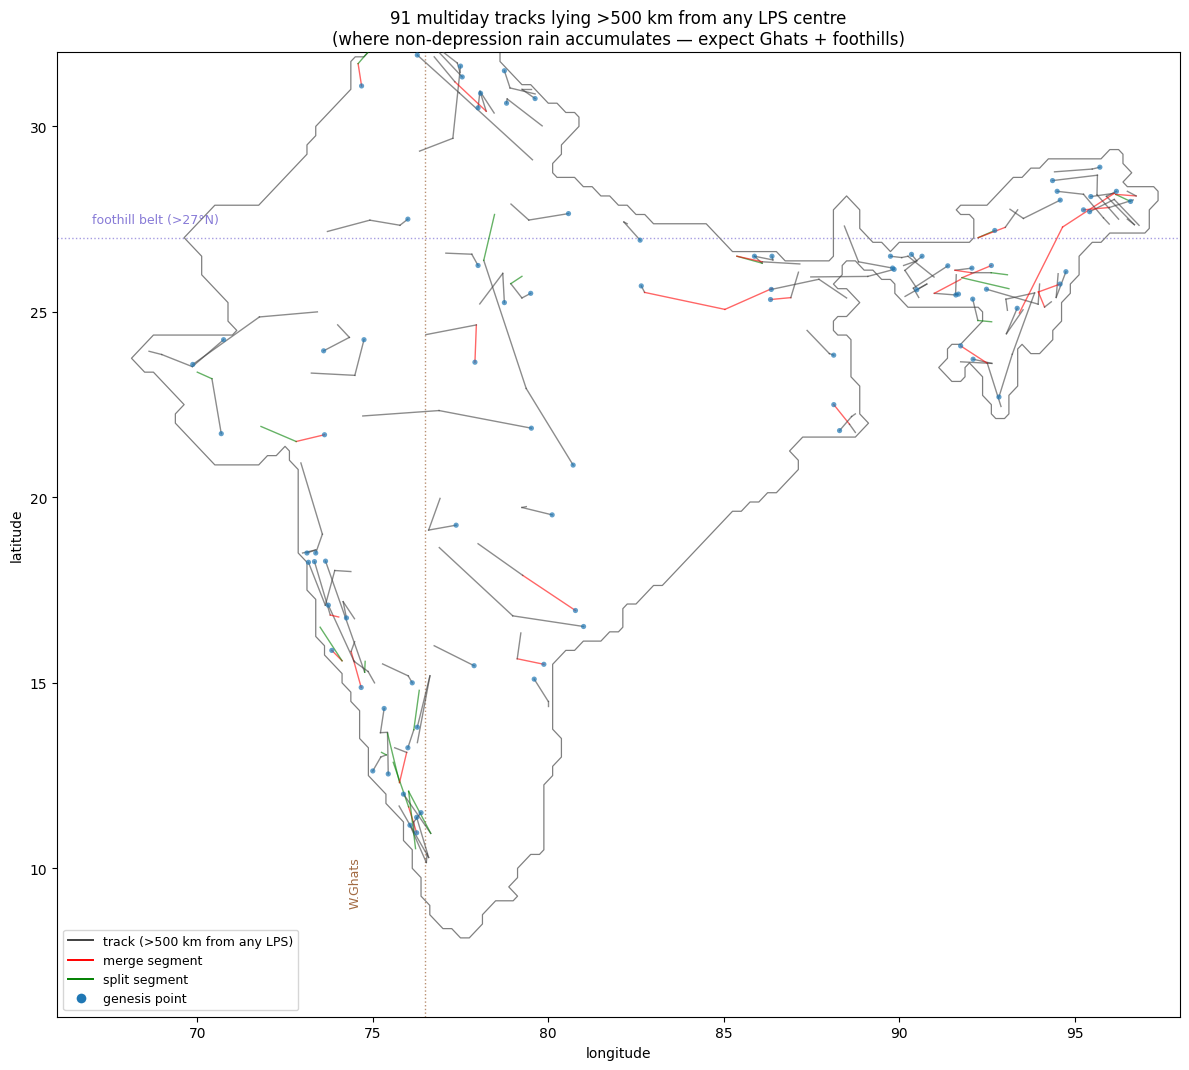

In [27]:
# ── Map : >500 km / never-matched 3+day tracks · merges red · splits green · NO LPS centres ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

md_tn   = summary_mean.loc[summary_mean.duration > 2, 'track_num']
per_trk = (stats_lps[stats_lps.matchable & stats_lps.track_num.isin(md_tn)]
           .groupby('track_num').nearest_lps_km.mean())
far_tn  = set(per_trk[per_trk > 500].index) | (set(md_tn) - set(per_trk.index))

LON, LAT = np.meshgrid(lon, lat)
fig, ax = plt.subplots(figsize=(12, 13))
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='0.5', linewidths=0.9, zorder=2)
# orographic reference lines so accumulation is readable
ax.axvline(76.5, color='saddlebrown', ls=':', lw=1, alpha=0.6, zorder=1)   # ~Ghats crest
ax.axhline(27,   color='slateblue',  ls=':', lw=1, alpha=0.6, zorder=1)    # ~foothill belt
ax.text(74.3, 9, 'W.Ghats', color='saddlebrown', fontsize=9, rotation=90, alpha=0.8)
ax.text(67, 27.4, 'foothill belt (>27°N)', color='slateblue', fontsize=9, alpha=0.8)

for tn in far_tn:
    g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    for k in range(len(g)-1):
        c = 'red' if bool(g.merge_event.iloc[k+1]) else ('green' if bool(g.split_event.iloc[k+1]) else '0.25')
        ax.plot(g.centroid_lon.iloc[k:k+2], g.centroid_lat.iloc[k:k+2], '-', color=c, lw=1.0, alpha=0.6, zorder=3)
    ax.scatter(g.centroid_lon.iloc[0], g.centroid_lat.iloc[0], s=14, color='tab:blue',
               edgecolor='none', alpha=0.7, zorder=4)                       # genesis dot

leg = [Line2D([0],[0],color='0.25',lw=1.4,label='track (>500 km from any LPS)'),
       Line2D([0],[0],color='red',lw=1.4,label='merge segment'),
       Line2D([0],[0],color='green',lw=1.4,label='split segment'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='tab:blue',markersize=8,label='genesis point')]
ax.legend(handles=leg, loc='lower left', fontsize=9)
ax.set_title(f"{len(far_tn)} multiday tracks lying >500 km from any LPS centre\n"
             "(where non-depression rain accumulates — expect Ghats + foothills)", fontsize=12)
ax.set_xlim(66, 98); ax.set_ylim(6, 32); ax.set_aspect(1.057)
ax.set_xlabel('longitude'); ax.set_ylabel('latitude'); plt.tight_layout(); plt.show()

top 20 best-matched 3+day pairs (mean km · track · LPS · shared d · dur · closest km):
  mean   123 | track  4803 ↔ LPS 10087 | 4 shared d | 4d | closest 95 km
  mean   159 | track  1268 ↔ LPS 8854 | 3 shared d | 4d | closest 77 km
  mean   159 | track  7926 ↔ LPS 11292 | 3 shared d | 6d | closest 120 km
  mean   167 | track  5812 ↔ LPS 10378 | 4 shared d | 4d | closest 118 km
  mean   180 | track  1943 ↔ LPS 9165 | 6 shared d | 6d | closest 110 km
  mean   183 | track  2590 ↔ LPS 9369 | 4 shared d | 4d | closest 119 km
  mean   188 | track  2296 ↔ LPS 9228 | 3 shared d | 4d | closest 166 km
  mean   194 | track  5504 ↔ LPS 10264 | 4 shared d | 4d | closest 119 km
  mean   201 | track  6204 ↔ LPS 10440 | 3 shared d | 3d | closest 170 km
  mean   205 | track  8770 ↔ LPS 11615 | 3 shared d | 3d | closest 176 km
  mean   206 | track  5249 ↔ LPS 10159 | 4 shared d | 4d | closest 186 km
  mean   210 | track  7383 ↔ LPS 11021 | 4 shared d | 5d | closest 127 km
  mean   218 | track  2024 ↔ LP

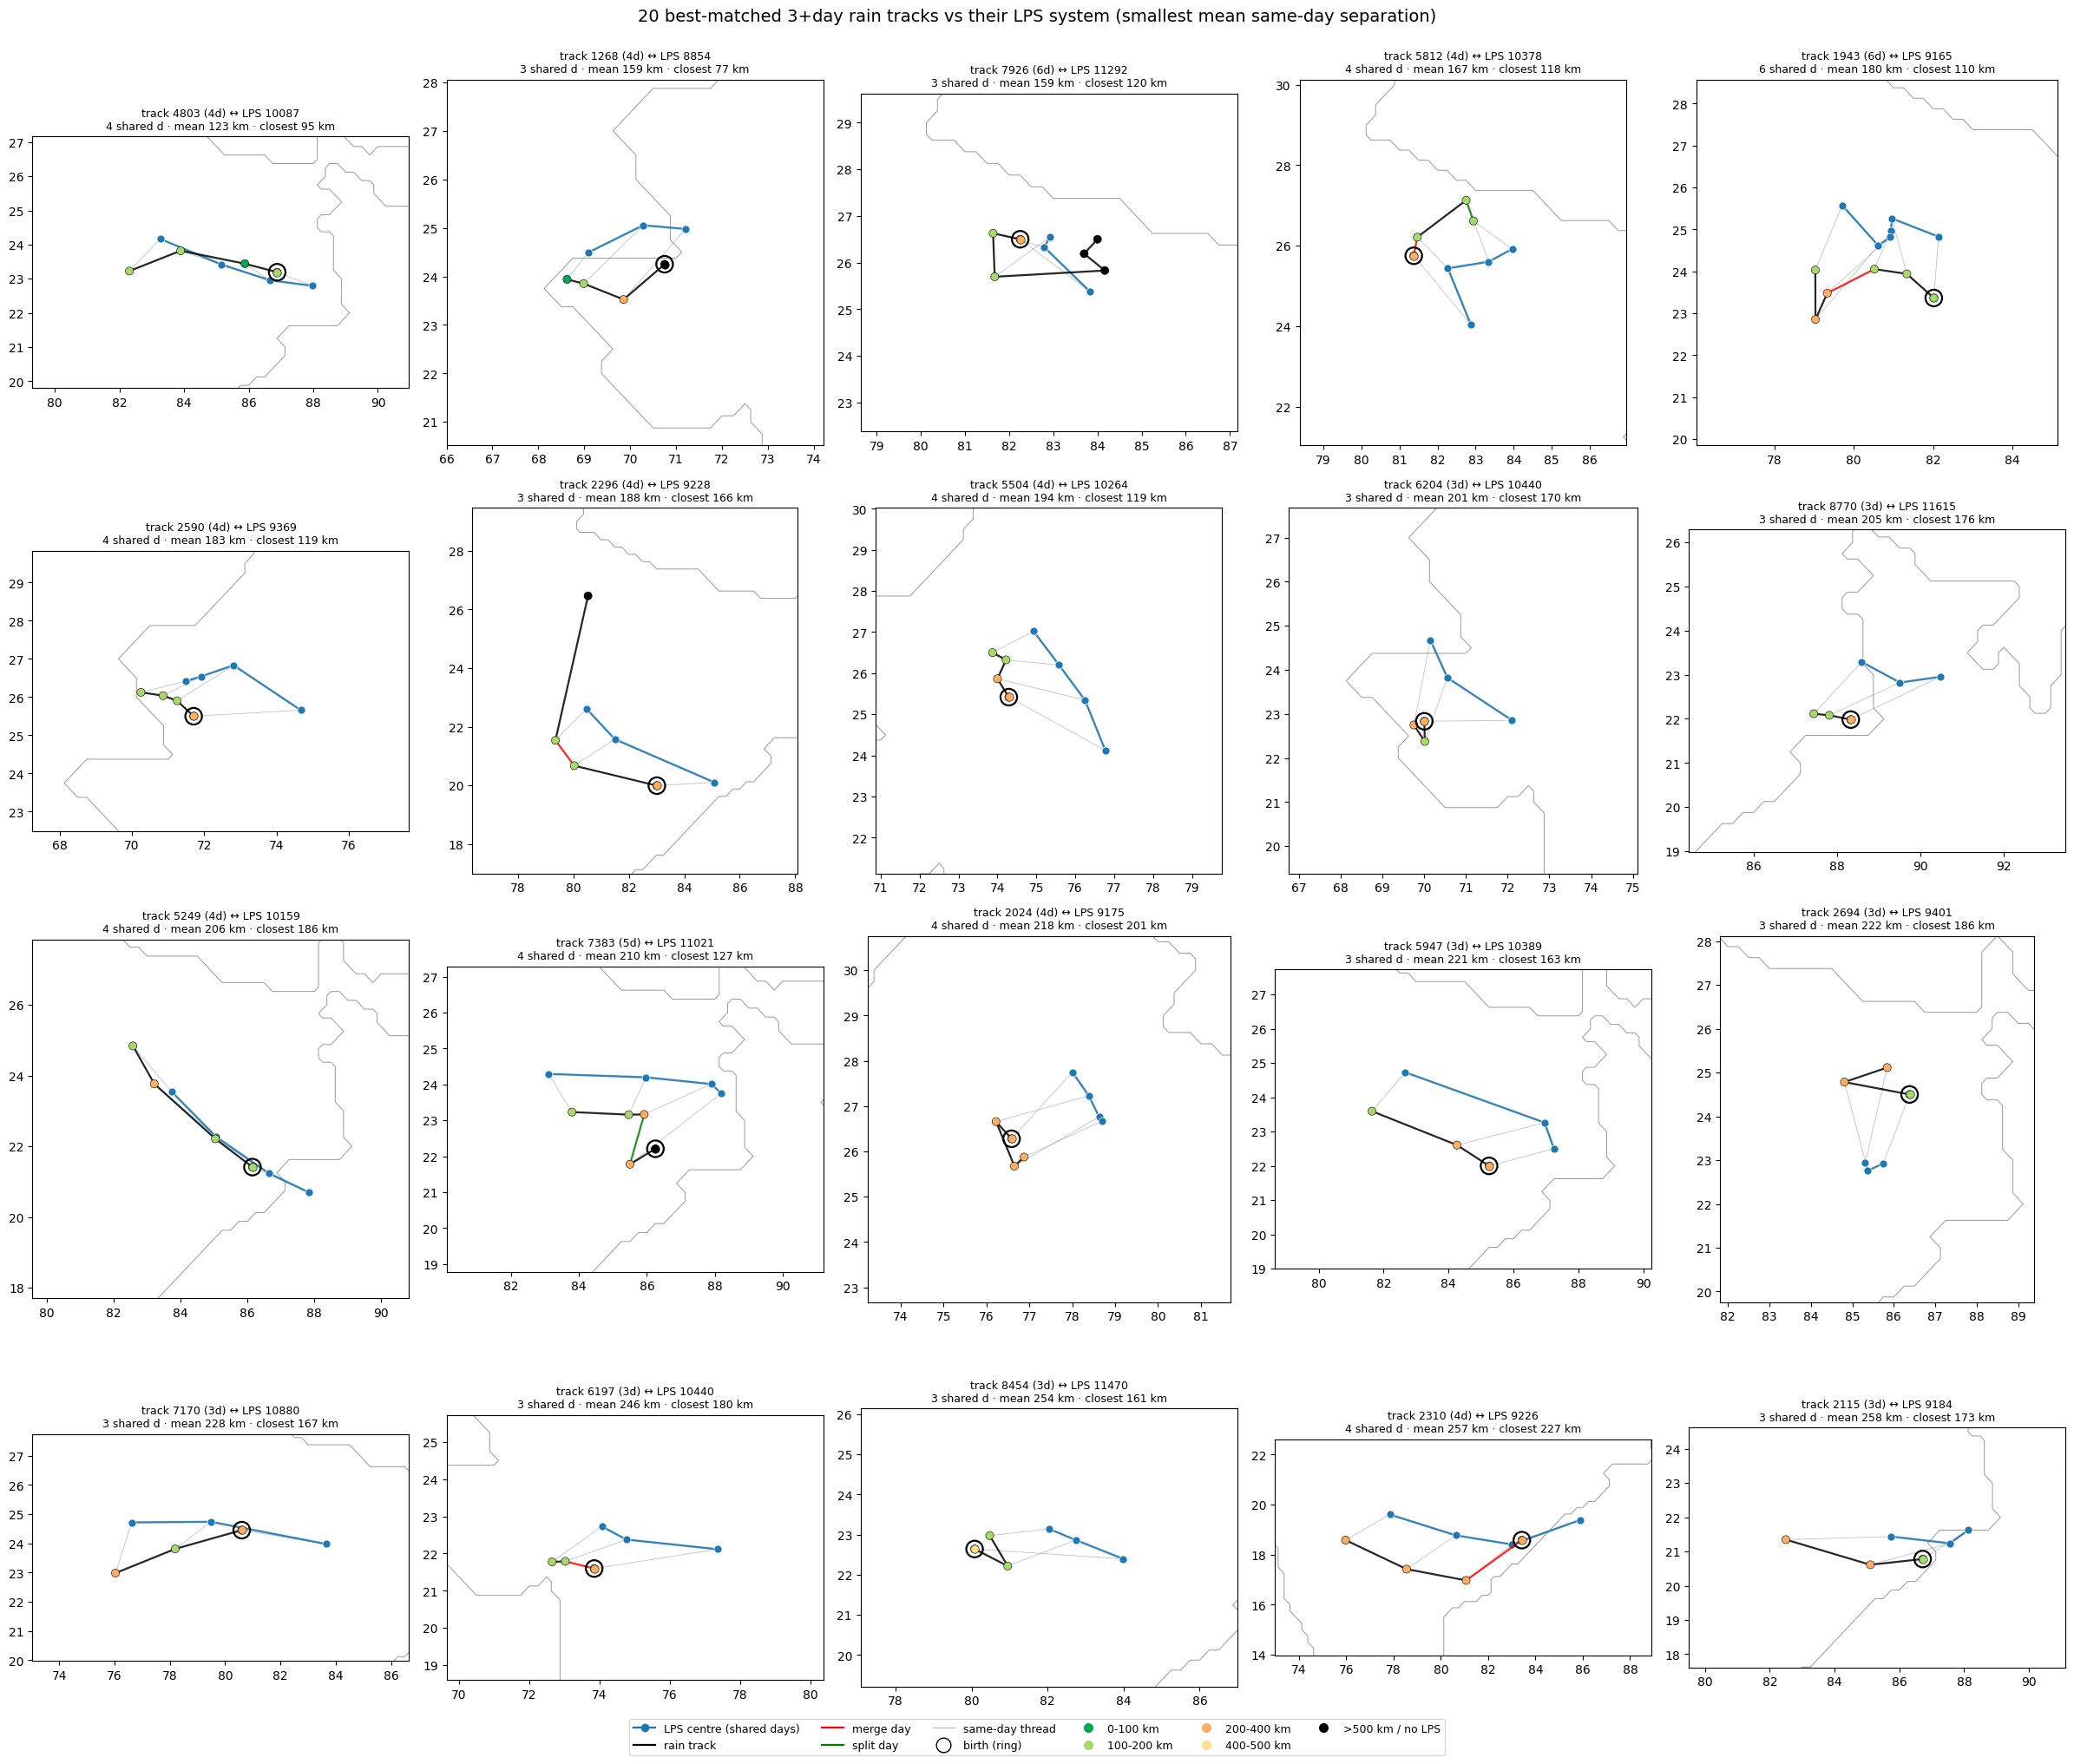

In [28]:
# ── Top 20 BEST-matched 3+day tracks · bands 0-100/100-200/200-400/400-500/>500 · birth ringed ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = 66, 98, 6, 32
MIN_SHARED = 3
def hav(la1, lo1, la2, lo2):
    R=6371.0088; p1,p2=np.radians(la1),np.radians(la2); dphi=p2-p1; dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))

# node colour bands (thread only when an LPS exists that day; >500 = filled black WITH thread;
# no-LPS-that-day = plain black dot, NO thread)
def band_color(d):
    if d != d:      return 'black'          # NaN → no LPS that day
    if d <= 100:    return '#00a651'        # 0-100   green
    if d <= 200:    return '#a6d96a'        # 100-200 light green
    if d <= 400:    return '#fdae61'        # 200-400 orange
    if d <= 500:    return '#fee08b'        # 400-500 light yellow
    return 'black'                          # >500    black (but threaded)

LON, LAT = np.meshgrid(lon, lat)
lps_clip  = lps_daily[(lps_daily.lon.between(LON_MIN,LON_MAX)) & (lps_daily.lat.between(LAT_MIN,LAT_MAX))]
lps_years = set(lps_clip.date.dt.year.unique())
md_tn = summary_mean[(summary_mean.duration > 2) & (summary_mean.year.isin(lps_years))].track_num

# score every (rain track, LPS system) pair sharing ≥MIN_SHARED days → smallest mean separation
scored = []
for tn in md_tn:
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    pts = dict(zip(gd, zip(g.centroid_lat, g.centroid_lon)))
    sub = lps_clip[lps_clip.date.isin(gd)]
    if not len(sub): continue
    for SYS, sc in sub.groupby('track_id'):
        shared = [d for d in sc.date if d in pts]
        if len(shared) < MIN_SHARED: continue
        sbd = dict(zip(sc.date, zip(sc.lat, sc.lon)))
        d2 = np.array([hav(*pts[d], *sbd[d]) for d in shared])
        scored.append((d2.mean(), tn, SYS, len(shared), int(g.duration.iloc[0]), float(d2.min())))
scored.sort(key=lambda x: x[0]); panels = scored[:20]
print("top 20 best-matched 3+day pairs (mean km · track · LPS · shared d · dur · closest km):")
for m,tn,SYS,ns,du,mn in panels:
    print(f"  mean {m:5.0f} | track {tn:>5} ↔ LPS {SYS} | {ns} shared d | {du}d | closest {mn:.0f} km")

fig, axes = plt.subplots(4, 5, figsize=(24, 20))
for ax, (mdist, tn, SYS, ns, dur, mn) in zip(axes.ravel(), panels):
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    sysc = lps_clip[lps_clip.track_id == SYS].sort_values('date')
    sbd  = dict(zip(sysc.date, zip(sysc.lat, sysc.lon)))
    sysc_sh = sysc[sysc.date.isin(set(gd))]                    # LPS on shared days only

    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='0.6', linewidths=0.7, zorder=1)

    # same-day threads (rain node → its centre) — drawn for ANY day an LPS exists, incl. >500 km
    for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon):
        if d in sbd:
            clat, clon = sbd[d]
            ax.plot([lo, clon], [la, clat], '-', color='0.6', lw=0.6, alpha=0.6, zorder=2)

    # LPS centre track (shared days): blue dots + blue line
    ax.plot(sysc_sh.lon, sysc_sh.lat, '-', color='tab:blue', lw=1.7, alpha=0.9, zorder=3)
    ax.scatter(sysc_sh.lon, sysc_sh.lat, s=42, color='tab:blue', edgecolor='white', lw=0.5, zorder=4)

    # rain track: black line, single red segment on merge day, single green on split day
    for k in range(len(g)-1):
        c = 'red' if bool(g.merge_event.iloc[k+1]) else ('green' if bool(g.split_event.iloc[k+1]) else 'black')
        ax.plot(g.centroid_lon.iloc[k:k+2], g.centroid_lat.iloc[k:k+2], '-', color=c, lw=1.6, alpha=0.85, zorder=5)

    # rain nodes coloured by same-day distance (NaN → plain black, no thread already handled above)
    dist = np.array([hav(la, lo, *sbd[d]) if d in sbd else np.nan
                     for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon)])
    cols = [band_color(d) for d in dist]
    ax.scatter(g.centroid_lon, g.centroid_lat, c=cols, s=44, edgecolor='k', lw=0.4, zorder=6)

    # BIRTH marker: hollow ring with a colour-coded dot of the first node inside
    b_lon, b_lat, b_col = g.centroid_lon.iloc[0], g.centroid_lat.iloc[0], cols[0]
    ax.scatter(b_lon, b_lat, s=190, facecolor='none', edgecolor='k', lw=1.6, zorder=7)
    ax.scatter(b_lon, b_lat, s=46,  color=b_col, edgecolor='k', lw=0.4, zorder=8)

    ax.set_title(f"track {tn} ({dur}d) ↔ LPS {SYS}\n{ns} shared d · mean {mdist:.0f} km · closest {mn:.0f} km", fontsize=9)
    pad = 3
    xs = pd.concat([g.centroid_lon, sysc_sh.lon]); ys = pd.concat([g.centroid_lat, sysc_sh.lat])
    ax.set_xlim(max(LON_MIN, xs.min()-pad), min(LON_MAX, xs.max()+pad))
    ax.set_ylim(max(LAT_MIN, ys.min()-pad), min(LAT_MAX, ys.max()+pad)); ax.set_aspect(1.057)

leg = [Line2D([0],[0],color='tab:blue',marker='o',lw=1.7,label='LPS centre (shared days)'),
       Line2D([0],[0],color='black',lw=1.6,label='rain track'),
       Line2D([0],[0],color='red',lw=1.6,label='merge day'),
       Line2D([0],[0],color='green',lw=1.6,label='split day'),
       Line2D([0],[0],color='0.6',lw=0.6,label='same-day thread'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='none',markeredgecolor='k',markersize=12,label='birth (ring)'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#00a651',markersize=9,label='0-100 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#a6d96a',markersize=9,label='100-200 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fdae61',markersize=9,label='200-400 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fee08b',markersize=9,label='400-500 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='black',markersize=9,label='>500 km / no LPS')]
fig.legend(handles=leg, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("20 best-matched 3+day rain tracks vs their LPS system (smallest mean same-day separation)",
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

10 longest matchable 3+day tracks (track · LPS · dur · shared d · mean km · closest km):
  track   322 ↔ LPS 8437 | 7d | 4 shared d | mean 323 km | closest 183 km
  track  2538 ↔ LPS 9357 | 7d | 7 shared d | mean 481 km | closest 363 km
  track  7926 ↔ LPS 11292 | 6d | 3 shared d | mean 159 km | closest 120 km
  track  2403 ↔ LPS 9333 | 6d | 6 shared d | mean 370 km | closest 258 km
  track  1943 ↔ LPS 9165 | 6d | 6 shared d | mean 180 km | closest 110 km
  track  2822 ↔ LPS 9492 | 5d | 5 shared d | mean 1044 km | closest 501 km
  track  6724 ↔ LPS 10715 | 5d | 5 shared d | mean 319 km | closest 187 km
  track  7383 ↔ LPS 11017 | 5d | 5 shared d | mean 1056 km | closest 788 km
  track  8037 ↔ LPS 11311 | 5d | 4 shared d | mean 1410 km | closest 1025 km
  track   841 ↔ LPS 8692 | 4d | 1 shared d | mean 1217 km | closest 1217 km


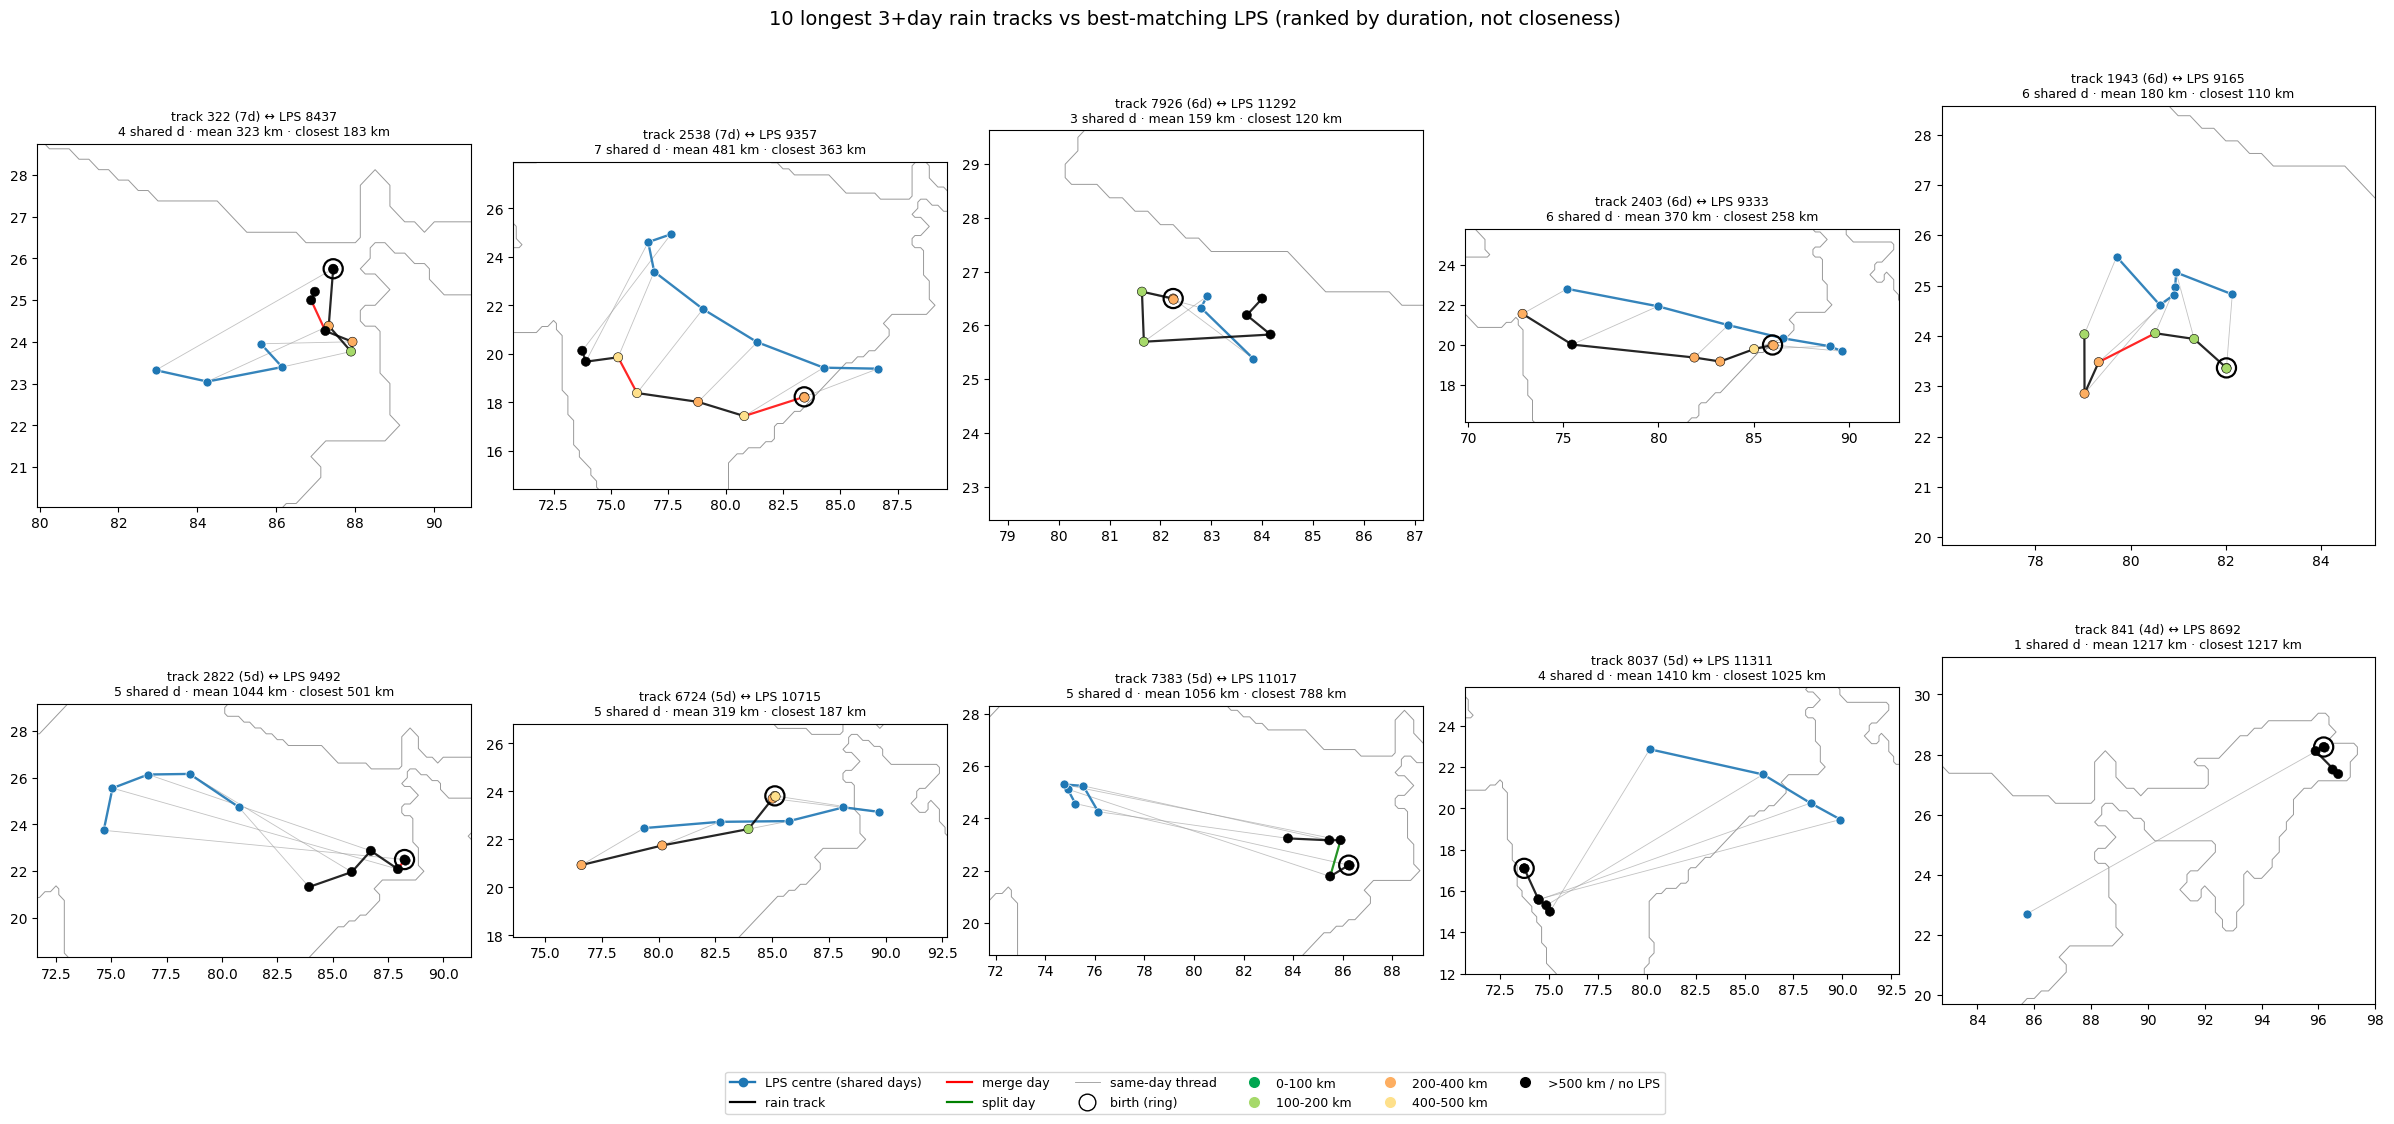

In [29]:
# ── 10 LONGEST 3+day tracks vs best-matching LPS · same conventions · bands 0-100/100-200/200-400/400-500/>500 ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = 66, 98, 6, 32
def hav(la1, lo1, la2, lo2):
    R=6371.0088; p1,p2=np.radians(la1),np.radians(la2); dphi=p2-p1; dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))

def band_color(d):
    if d != d:      return 'black'          # no LPS that day
    if d <= 100:    return '#00a651'
    if d <= 200:    return '#a6d96a'
    if d <= 400:    return '#fdae61'
    if d <= 500:    return '#fee08b'
    return 'black'                          # >500 (threaded)

LON, LAT = np.meshgrid(lon, lat)
lps_clip  = lps_daily[(lps_daily.lon.between(LON_MIN,LON_MAX)) & (lps_daily.lat.between(LAT_MIN,LAT_MAX))]
lps_years = set(lps_clip.date.dt.year.unique())
cand = summary_mean[(summary_mean.duration > 2) & (summary_mean.year.isin(lps_years))] \
        .sort_values('duration', ascending=False)

# for each candidate (longest first): pick LPS sharing the MOST days (tiebreak tightest mean)
panels = []
for tn in cand.track_num:
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    pts = dict(zip(gd, zip(g.centroid_lat, g.centroid_lon)))
    sub = lps_clip[lps_clip.date.isin(gd)]
    if not len(sub): continue
    best = None
    for SYS, sc in sub.groupby('track_id'):
        shared = [d for d in sc.date if d in pts]
        if not shared: continue
        sbd = dict(zip(sc.date, zip(sc.lat, sc.lon)))
        d2  = np.array([hav(*pts[d], *sbd[d]) for d in shared])
        key = (len(shared), -d2.mean())                 # most shared days, then tightest
        if best is None or key > best[0]:
            best = (key, SYS, len(shared), float(d2.mean()), float(d2.min()))
    if best is None: continue
    _, SYS, ns, mmean, mmin = best
    panels.append((tn, SYS, int(g.duration.iloc[0]), ns, mmean, mmin))
    if len(panels) == 10: break

print("10 longest matchable 3+day tracks (track · LPS · dur · shared d · mean km · closest km):")
for tn,SYS,du,ns,mm,mn in panels:
    print(f"  track {tn:>5} ↔ LPS {SYS} | {du}d | {ns} shared d | mean {mm:.0f} km | closest {mn:.0f} km")

fig, axes = plt.subplots(2, 5, figsize=(24, 11))
for ax, (tn, SYS, dur, ns, mmean, mmin) in zip(axes.ravel(), panels):
    g  = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    gd = pd.to_datetime(g.date, format='%Y%m%d')
    sysc = lps_clip[lps_clip.track_id == SYS].sort_values('date')
    sbd  = dict(zip(sysc.date, zip(sysc.lat, sysc.lon)))
    sysc_sh = sysc[sysc.date.isin(set(gd))]

    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='0.6', linewidths=0.7, zorder=1)

    # same-day threads (any day an LPS exists, incl. >500 km)
    for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon):
        if d in sbd:
            clat, clon = sbd[d]
            ax.plot([lo, clon], [la, clat], '-', color='0.6', lw=0.6, alpha=0.6, zorder=2)

    # LPS centre track (shared days): blue dots + line
    ax.plot(sysc_sh.lon, sysc_sh.lat, '-', color='tab:blue', lw=1.7, alpha=0.9, zorder=3)
    ax.scatter(sysc_sh.lon, sysc_sh.lat, s=42, color='tab:blue', edgecolor='white', lw=0.5, zorder=4)

    # rain track: black, single red segment on merge day, single green on split day
    for k in range(len(g)-1):
        c = 'red' if bool(g.merge_event.iloc[k+1]) else ('green' if bool(g.split_event.iloc[k+1]) else 'black')
        ax.plot(g.centroid_lon.iloc[k:k+2], g.centroid_lat.iloc[k:k+2], '-', color=c, lw=1.6, alpha=0.85, zorder=5)

    dist = np.array([hav(la, lo, *sbd[d]) if d in sbd else np.nan
                     for d, la, lo in zip(gd, g.centroid_lat, g.centroid_lon)])
    cols = [band_color(d) for d in dist]
    ax.scatter(g.centroid_lon, g.centroid_lat, c=cols, s=44, edgecolor='k', lw=0.4, zorder=6)

    # BIRTH: hollow ring + colour-coded first-node dot inside
    b_lon, b_lat, b_col = g.centroid_lon.iloc[0], g.centroid_lat.iloc[0], cols[0]
    ax.scatter(b_lon, b_lat, s=190, facecolor='none', edgecolor='k', lw=1.6, zorder=7)
    ax.scatter(b_lon, b_lat, s=46,  color=b_col, edgecolor='k', lw=0.4, zorder=8)

    ax.set_title(f"track {tn} ({dur}d) ↔ LPS {SYS}\n{ns} shared d · mean {mmean:.0f} km · closest {mmin:.0f} km", fontsize=9)
    pad = 3
    xs = pd.concat([g.centroid_lon, sysc_sh.lon]); ys = pd.concat([g.centroid_lat, sysc_sh.lat])
    ax.set_xlim(max(LON_MIN, xs.min()-pad), min(LON_MAX, xs.max()+pad))
    ax.set_ylim(max(LAT_MIN, ys.min()-pad), min(LAT_MAX, ys.max()+pad)); ax.set_aspect(1.057)

leg = [Line2D([0],[0],color='tab:blue',marker='o',lw=1.7,label='LPS centre (shared days)'),
       Line2D([0],[0],color='black',lw=1.6,label='rain track'),
       Line2D([0],[0],color='red',lw=1.6,label='merge day'),
       Line2D([0],[0],color='green',lw=1.6,label='split day'),
       Line2D([0],[0],color='0.6',lw=0.6,label='same-day thread'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='none',markeredgecolor='k',markersize=12,label='birth (ring)'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#00a651',markersize=9,label='0-100 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#a6d96a',markersize=9,label='100-200 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fdae61',markersize=9,label='200-400 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='#fee08b',markersize=9,label='400-500 km'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor='black',markersize=9,label='>500 km / no LPS')]
fig.legend(handles=leg, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("10 longest 3+day rain tracks vs best-matching LPS (ranked by duration, not closeness)",
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()